In [1]:
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

orders   = pd.read_csv('/content/drive/MyDrive/olist_orders_dataset.csv',
                       parse_dates=['order_purchase_timestamp',
                                    'order_approved_at',
                                    'order_delivered_carrier_date',
                                    'order_delivered_customer_date',
                                    'order_estimated_delivery_date']) # use parse_date porque como haremos un analisis temporal mensual y necesitamos
                                                                      # que no lo lea como objeto sino q respete datetime
                                                                      # para calcular tiempos de entrega, agrupar por mes y analizar la demanda por tiempo.

items    = pd.read_csv('/content/drive/MyDrive/olist_order_items_dataset.csv')
products = pd.read_csv('/content/drive/MyDrive/olist_products_dataset.csv')
reviews  = pd.read_csv('/content/drive/MyDrive/olist_order_reviews_dataset.csv')
payments = pd.read_csv('/content/drive/MyDrive/olist_order_payments_dataset.csv')
customers = pd.read_csv('/content/drive/MyDrive/olist_customers_dataset.csv')
sellers = pd.read_csv('/content/drive/MyDrive/olist_sellers_dataset.csv')



Mounted at /content/drive


In [2]:
# ============================================
# Demanda mensual cruda por categoría
# ============================================

# Aseguramos tipos de fecha
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Solo órdenes entregadas
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

# Unir items con información de órdenes (order_purchase_timestamp)
# y luego con categorías de productos.
# Se corrige para que la base sea 'items' que contiene 'product_id' y 'order_id'.
items_with_order_info = items.merge(
    orders_delivered[['order_id', 'order_purchase_timestamp']],
    on='order_id',
    how='inner'
)

# Agregar categoría desde products
items_orders = items_with_order_info.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# Mes de la orden
items_orders['order_month'] = items_orders['order_purchase_timestamp'].dt.to_period('M')

# Agregación cruda por categoría × mes
monthly_raw = (
    items_orders
    .groupby(['product_category_name', 'order_month'])
    .agg(
        demand=('order_id', 'count'),           # líneas de pedido = proxy de demanda
        total_price=('price', 'sum'),
        unique_orders=('order_id', 'nunique')
    )
    .reset_index()
)

monthly_raw['date'] = monthly_raw['order_month'].dt.to_timestamp()

# Target desde crudo: demanda del mes siguiente
monthly_raw = monthly_raw.sort_values(['product_category_name', 'date'])
monthly_raw['demand_next_month'] = (
    monthly_raw
    .groupby('product_category_name')['demand']
    .shift(-1)
)

monthly_raw.head()

,product_category_name,order_month,demand,total_price,unique_orders,date,demand_next_month
0,agro_industria_e_comercio,2017-01,3,65.97,2,2017-01-01,7.0
1,agro_industria_e_comercio,2017-02,7,224.84,7,2017-02-01,2.0
2,agro_industria_e_comercio,2017-03,2,81.99,2,2017-03-01,4.0
3,agro_industria_e_comercio,2017-05,4,1579.94,4,2017-05-01,1.0
4,agro_industria_e_comercio,2017-06,1,1390.00,1,2017-06-01,1.0


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

monthly_raw['demand_next_month'] = (
    monthly_raw
        .groupby('product_category_name')['demand']
        .shift(-1)
)

# Aseguramos orden correcto
monthly_raw = monthly_raw.sort_values(['product_category_name', 'date'])

# Elegimos una categoría representativa (la de mayor demanda total)
cat_demo = (
    monthly_raw.groupby('product_category_name')['demand']
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

print("Categoría de ejemplo:", cat_demo)

demo = monthly_raw[monthly_raw['product_category_name'] == cat_demo].copy()

# Mes t y mes t+1 como Period (para verlo clarito)
demo['month_t']  = demo['date'].dt.to_period('M')
demo['month_t1'] = demo['month_t'] + 1  # mes siguiente

# Tabla “t / t+1” sin NaN en la target
tabla_demo = demo[['product_category_name', 'month_t', 'demand', 'month_t1', 'demand_next_month']].dropna()

tabla_demo.rename(columns={
    'product_category_name': 'categoria',
    'month_t': 'mes_t',
    'demand': 'demanda_mes_t',
    'month_t1': 'mes_t+1',
    'demand_next_month': 'demanda_mes_t+1'
}, inplace=True)

tabla_demo.head(10)

Categoría de ejemplo: cama_mesa_banho


,categoria,mes_t,demanda_mes_t,mes_t+1,demanda_mes_t+1
232,cama_mesa_banho,2016-10,8,2016-11,46.0
233,cama_mesa_banho,2017-01,46,2017-02,157.0
234,cama_mesa_banho,2017-02,157,2017-03,279.0
235,cama_mesa_banho,2017-03,279,2017-04,271.0
236,cama_mesa_banho,2017-04,271,2017-05,361.0
237,cama_mesa_banho,2017-05,361,2017-06,369.0
238,cama_mesa_banho,2017-06,369,2017-07,569.0
239,cama_mesa_banho,2017-07,569,2017-08,506.0
240,cama_mesa_banho,2017-08,506,2017-09,528.0
241,cama_mesa_banho,2017-09,528,2017-10,542.0


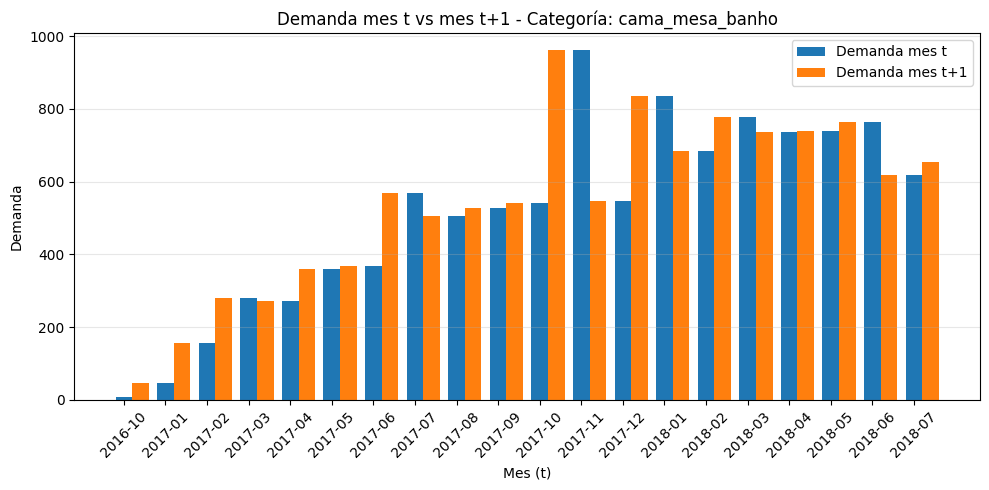

In [4]:
# Usamos la tabla ya creada (tabla_demo)
x = tabla_demo.copy()

plt.figure(figsize=(10,5))
indices = range(len(x))

plt.bar(indices, x['demanda_mes_t'], width=0.4, label='Demanda mes t', align='edge')
plt.bar([i+0.4 for i in indices], x['demanda_mes_t+1'], width=0.4, label='Demanda mes t+1', align='edge')

plt.xticks([i+0.2 for i in indices], x['mes_t'].astype(str), rotation=45)
plt.xlabel("Mes (t)")
plt.ylabel("Demanda")
plt.title(f"Demanda mes t vs mes t+1 - Categoría: {cat_demo}")
plt.legend()
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()


In [5]:
total_filas = len(monthly_raw)
filas_con_target = monthly_raw['demand_next_month'].notna().sum()

print("Filas totales en monthly_raw      :", total_filas)
print("Filas con demand_next_month válida:", filas_con_target)
print("Proporción con target:",
      round(filas_con_target / total_filas, 3))


Filas totales en monthly_raw      : 1252
Filas con demand_next_month válida: 1179
Proporción con target: 0.942


In [6]:
filas_por_cat = monthly_raw.groupby('product_category_name').size()
filas_con_target_cat = (
    monthly_raw.dropna(subset=['demand_next_month'])
    .groupby('product_category_name').size()
)

delta = filas_por_cat - filas_con_target_cat
print("Diferencia (filas sin target) por categoría:")
print(delta.value_counts())


Diferencia (filas sin target) por categoría:
1    73
Name: count, dtype: int64


In [7]:
valid = monthly_raw.dropna(subset=['demand_next_month']).copy()

corr_global = valid['demand'].corr(valid['demand_next_month'])
print("Correlación global demand_t vs demand_{t+1}:", corr_global)

corrs = []
for cat, grp in monthly_raw.groupby('product_category_name'):
    g = grp.dropna(subset=['demand_next_month'])
    if len(g) >= 3:
        corrs.append(g['demand'].corr(g['demand_next_month']))

print("Número categorías:", len(corrs))
print("Mediana corr categórica:", np.nanmedian(corrs))


Correlación global demand_t vs demand_{t+1}: 0.9463605517760679
Número categorías: 71
Mediana corr categórica: 0.6090576067149711


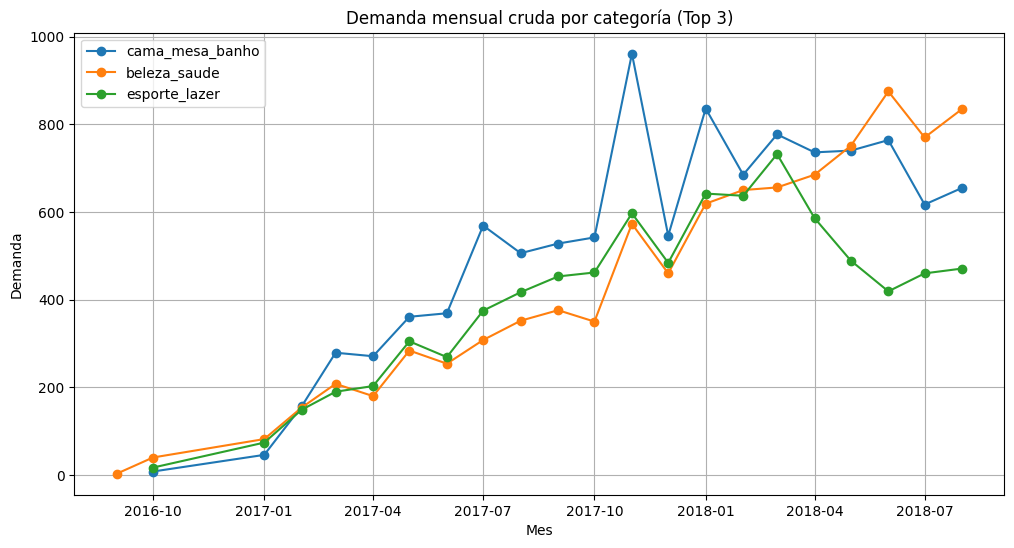

In [8]:
top_cats = (
    monthly_raw.groupby('product_category_name')['demand']
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index.tolist()
)

plt.figure(figsize=(12,6))
for cat in top_cats:
    sub = monthly_raw[monthly_raw['product_category_name'] == cat]
    plt.plot(sub['date'], sub['demand'], marker='o', label=cat)

plt.title("Demanda mensual cruda por categoría (Top 3)")
plt.xlabel("Mes")
plt.ylabel("Demanda")
plt.legend()
plt.grid(True)
plt.show()


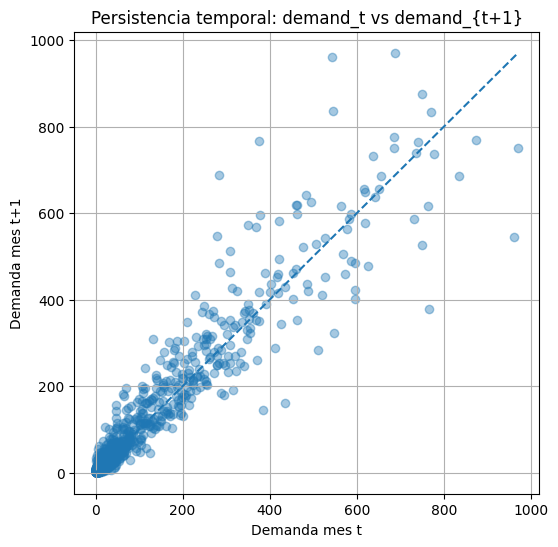

In [9]:
plt.figure(figsize=(6,6))
plt.scatter(valid['demand'], valid['demand_next_month'], alpha=0.4)
plt.title("Persistencia temporal: demand_t vs demand_{t+1}")
plt.xlabel("Demanda mes t")
plt.ylabel("Demanda mes t+1")
plt.grid(True)
max_val = max(valid['demand'].max(), valid['demand_next_month'].max())
plt.plot([0, max_val], [0, max_val], '--')
plt.show()


<Axes: xlabel='month'>

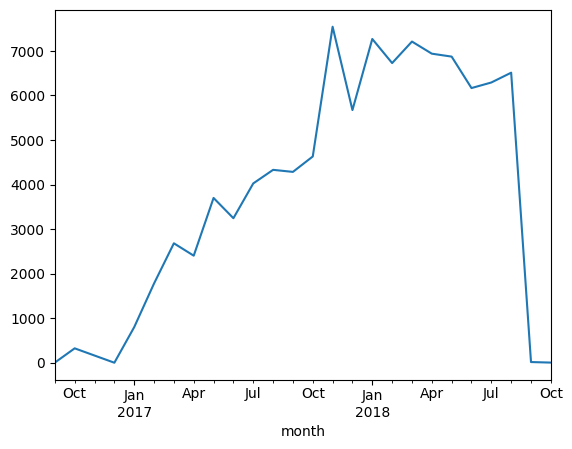

In [10]:
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = orders.groupby('month')['order_id'].count()
monthly_orders.plot()


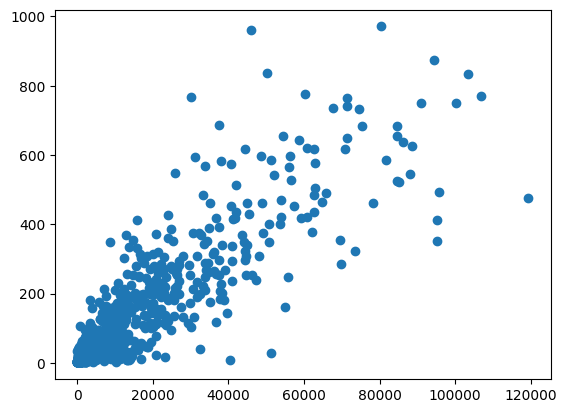

In [11]:
plt.scatter(valid['total_price'], valid['demand_next_month'])

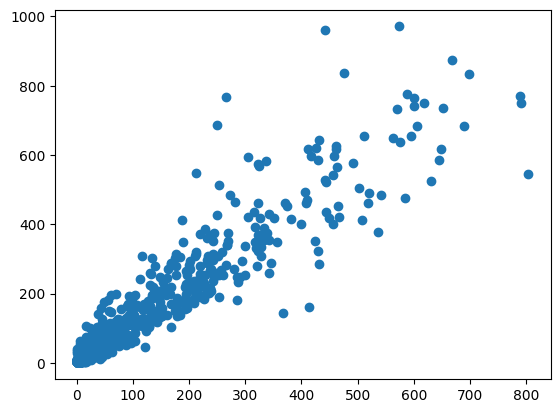

In [12]:
plt.scatter(valid['unique_orders'], valid['demand_next_month'])


In [15]:
payments.groupby('payment_installments')['payment_value'].sum()

,payment_value
payment_installments,
0,188.63
1,5907233.36
2,1579283.03
3,1491103.80
4,1163907.61
5,961174.30
6,822611.81
7,305157.39
8,1313423.34


In [16]:
reviews_per_month = reviews.groupby(reviews['review_creation_date'].dt.to_period('M'))['review_score'].mean()

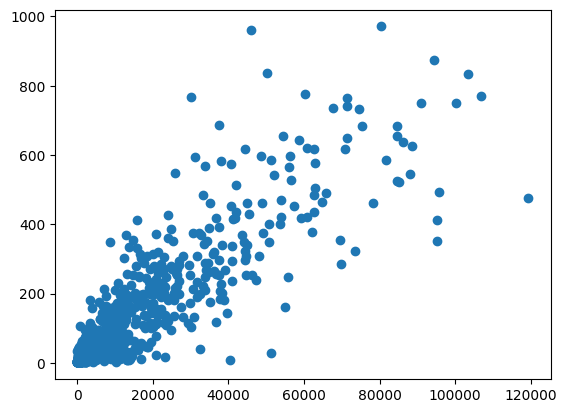

In [13]:
plt.scatter(valid['total_price'], valid['demand_next_month'])


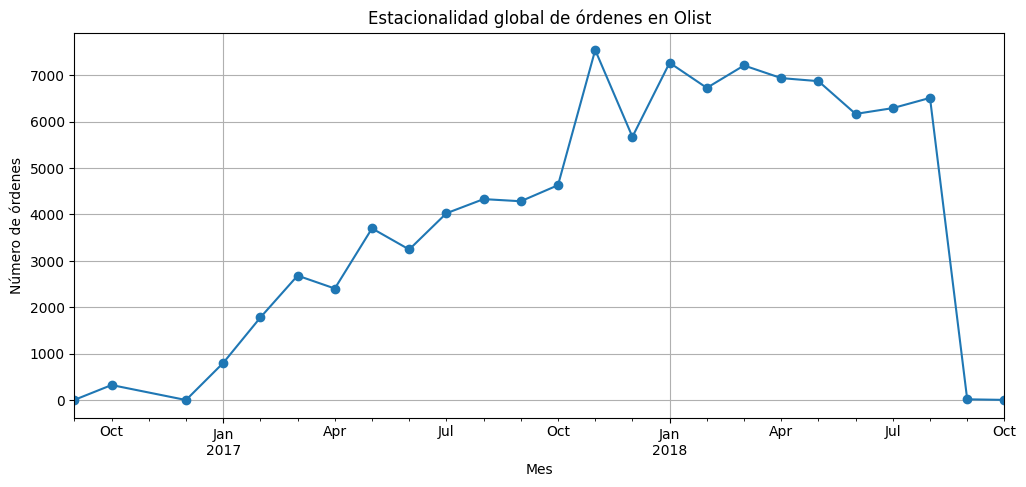

In [14]:
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = orders.groupby('month')['order_id'].count()

plt.figure(figsize=(12,5))
monthly_orders.plot(marker='o')
plt.title('Estacionalidad global de órdenes en Olist')
plt.xlabel('Mes')
plt.ylabel('Número de órdenes')
plt.grid(True)
plt.show()


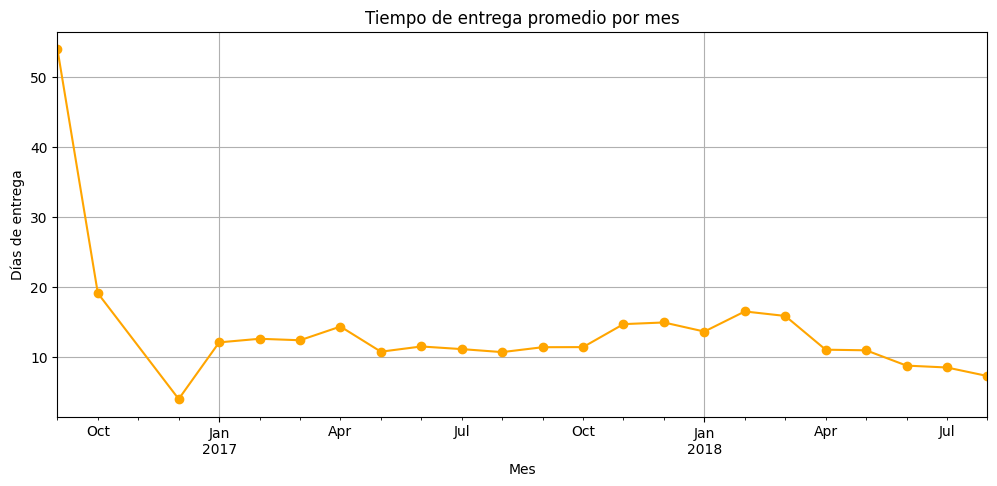

In [15]:
orders['delivery_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

delivery_monthly = (
    orders.dropna(subset=['delivery_days'])
    .groupby(orders['order_purchase_timestamp'].dt.to_period('M'))['delivery_days']
    .mean()
)

plt.figure(figsize=(12,5))
delivery_monthly.plot(marker='o', color='orange')
plt.title('Tiempo de entrega promedio por mes')
plt.xlabel('Mes')
plt.ylabel('Días de entrega')
plt.grid(True)
plt.show()


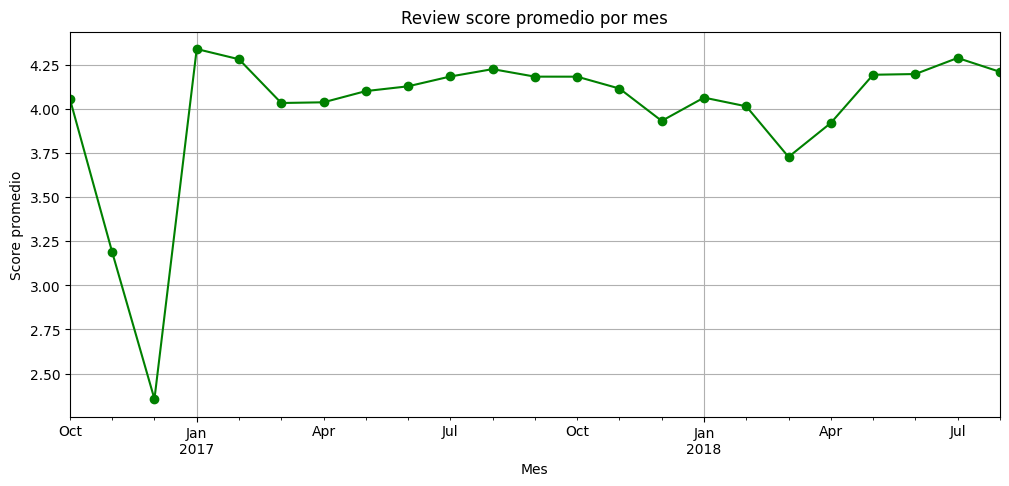

In [16]:
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])

reviews_monthly = (
    reviews
    .groupby(reviews['review_creation_date'].dt.to_period('M'))['review_score']
    .mean()
)

plt.figure(figsize=(12,5))
reviews_monthly.plot(marker='o', color='green')
plt.title('Review score promedio por mes')
plt.xlabel('Mes')
plt.ylabel('Score promedio')
plt.grid(True)
plt.show()


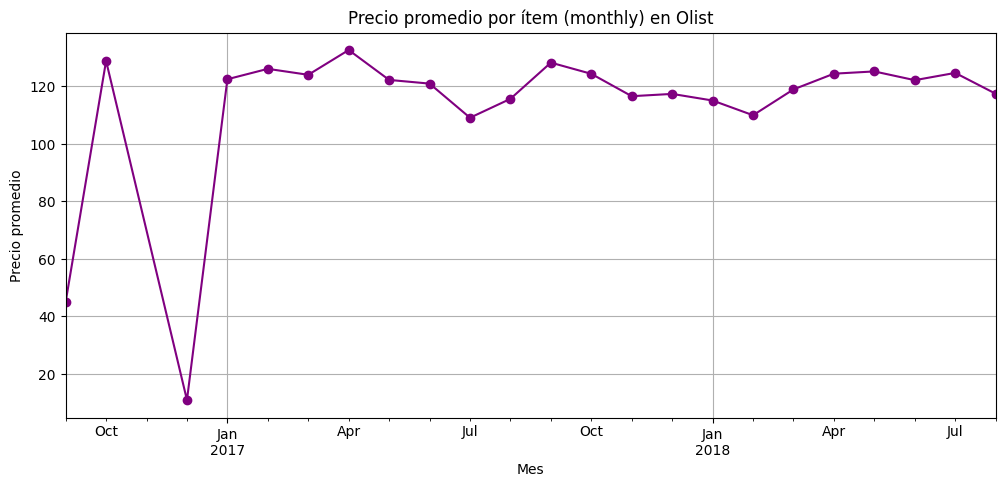

In [17]:
items['price'] = items['price'].astype(float)

items_orders['month'] = items_orders['order_purchase_timestamp'].dt.to_period('M')
price_monthly = items_orders.groupby('month')['price'].mean()

plt.figure(figsize=(12,5))
price_monthly.plot(marker='o', color='purple')
plt.title('Precio promedio por ítem (monthly) en Olist')
plt.xlabel('Mes')
plt.ylabel('Precio promedio')
plt.grid(True)
plt.show()


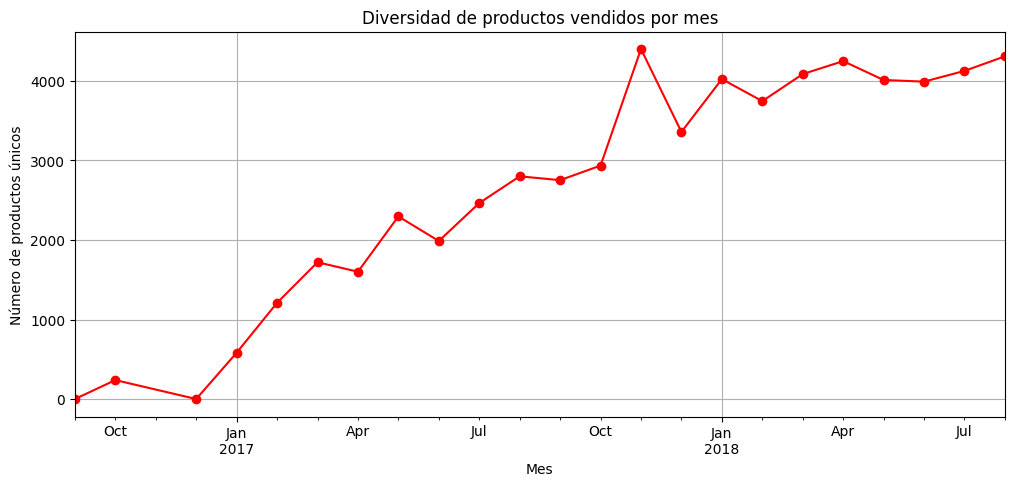

In [18]:
items_orders['month'] = items_orders['order_purchase_timestamp'].dt.to_period('M')

product_diversity = (
    items_orders
    .groupby('month')['product_id']
    .nunique()
)

plt.figure(figsize=(12,5))
product_diversity.plot(marker='o', color='red')
plt.title('Diversidad de productos vendidos por mes')
plt.xlabel('Mes')
plt.ylabel('Número de productos únicos')
plt.grid(True)
plt.show()


In [19]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


# ===========================================
# 1. LIMPIEZA DE orders
# ===========================================

print("Limpieza de ORDERS...")

orders_clean = orders.copy()

# 1.1 Fechas a datetime (asegurando tipos correctos)
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col], errors='coerce')

# 1.2 Filtrar solo órdenes válidas y entregadas
# - Estado delivered
# - La orden fue aprobada antes (o el mismo día) que el carrier la recoge
orders_clean = orders_clean[
    (orders_clean['order_status'].str.lower().str.strip() == 'delivered') &
    (orders_clean['order_approved_at'] <= orders_clean['order_delivered_carrier_date'])
].copy()

# 1.3 Normalizar estado del pedido
orders_clean['order_status'] = orders_clean['order_status'].str.lower().str.strip()

# 1.4 Eliminar duplicados por order_id
orders_clean = orders_clean.drop_duplicates(subset=['order_id'])

# 1.5 Quitar registros donde la fecha de compra está vacía
orders_clean = orders_clean.dropna(subset=['order_purchase_timestamp'])

# 1.6 Corregir posibles órdenes con fechas invertidas
mask = orders_clean['order_delivered_customer_date'] < orders_clean['order_delivered_carrier_date']
orders_clean.loc[mask, 'order_delivered_customer_date'] = np.nan

# 1.7 Crear variables temporales básicas (a nivel orden)
orders_clean['purchase_year'] = orders_clean['order_purchase_timestamp'].dt.year
orders_clean['purchase_month'] = orders_clean['order_purchase_timestamp'].dt.month
orders_clean['purchase_day'] = orders_clean['order_purchase_timestamp'].dt.day

# 1.8 Calcular tiempos de entrega en HORAS
orders_clean['time_to_approve_hr'] = (
    orders_clean['order_approved_at'] - orders_clean['order_purchase_timestamp']
).dt.total_seconds() / 3600

orders_clean['time_to_carrier_hr'] = (
    orders_clean['order_delivered_carrier_date'] - orders_clean['order_approved_at']
).dt.total_seconds() / 3600

orders_clean['time_to_customer_hr'] = (
    orders_clean['order_delivered_customer_date'] - orders_clean['order_delivered_carrier_date']
).dt.total_seconds() / 3600

orders_clean['total_delivery_time_hr'] = (
    orders_clean['order_delivered_customer_date'] - orders_clean['order_purchase_timestamp']
).dt.total_seconds() / 3600

orders_clean['delivery_delay_hr'] = (
    orders_clean['order_delivered_customer_date'] - orders_clean['order_estimated_delivery_date']
).dt.total_seconds() / 3600

# 1.9 Filtrar rango temporal del proyecto (2016-10 a 2018-08)
orders_clean = orders_clean[
    (orders_clean['order_purchase_timestamp'] >= '2016-10-01') &
    (orders_clean['order_purchase_timestamp'] <= '2018-08-31')
].copy()

# 1.10 Crear variables en DÍAS que usa el resto del pipeline
orders_clean['order_month'] = orders_clean['order_purchase_timestamp'].dt.to_period('M').astype(str)

orders_clean['delivery_time_days'] = (
    orders_clean['order_delivered_customer_date'] - orders_clean['order_purchase_timestamp']
).dt.days

orders_clean['delivery_delay'] = (
    orders_clean['order_delivered_customer_date'] - orders_clean['order_estimated_delivery_date']
).dt.days

# Si delivery_delay es NaN (por fechas faltantes) lo ponemos en 0 para no romper agregaciones
orders_clean['delivery_delay'] = orders_clean['delivery_delay'].fillna(0)

orders_clean['is_delayed'] = (orders_clean['delivery_delay'] > 0).astype(int)

print("ORDERS listo:", orders_clean.shape)
orders_clean.head()


# ==================================================
# 2. LIMPIEZA DE items
# ==================================================

items_clean = items.copy()

print("\nLimpieza de ITEMS...")

# yam Convertir fecha límite de envío
items_clean['shipping_limit_date'] = pd.to_datetime(items_clean['shipping_limit_date'], errors='coerce')

# 2.1. Eliminar duplicados completos
items_clean = items_clean.drop_duplicates()

# 2.2. Asegurar tipos correctos
items_clean['order_item_id'] = items_clean['order_item_id'].astype(int)
#yam
items_clean['price'] = items_clean['price'].astype(float)
items_clean['freight_value'] = items_clean['freight_value'].astype(float)


# yam Eliminar duplicados por order_id + order_item_id
items_clean = items_clean.drop_duplicates(subset=['order_id', 'order_item_id'])

# 2.3. Quitar precios negativos o cero (errores de origen)
items_clean = items_clean[items_clean['price'] > 0]

# 2.4. Freight no puede ser negativo
items_clean = items_clean[items_clean['freight_value'] >= 0]

print("ITEMS listo:", items_clean.shape)

# ===================================================
# 3. LIMPIEZA DE products
# ===================================================

products_clean = products.copy()

print("\nLimpieza de PRODUCTS...")

# 3.1. Normalizar nombres de categorías
products_clean['product_category_name'] = (
    products_clean['product_category_name']
        .astype(str)
        .str.lower()
        .str.replace(" ", "_")
)
# yam Reemplazar nulos en categoría
products_clean['product_category_name'] = products_clean['product_category_name'].fillna("unknown")

# 3.2. Convertir dimensiones a numéricas
cols_num = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for c in cols_num:
    products_clean[c] = pd.to_numeric(products_clean[c], errors='coerce')

# yam Imputación simple (mediana)
for c in cols_num:
    median_value = products_clean[c].median()
    products_clean[c] = products_clean[c].fillna(median_value)

# yam Remover productos con dimensiones o peso negativos
for c in cols_num:
    products_clean = products_clean[products_clean[c] >= 0]

# 3.3. Quitar duplicados
products_clean = products_clean.drop_duplicates(subset=['product_id'])

print("PRODUCTS listo:", products_clean.shape)


# ==================================================
# 4. LIMPIEZA DE payments
# ==================================================

payments_clean = payments.copy()

print("\nLimpieza de PAYMENTS...")

# yam Normalizar tipo de pago
payments_clean['payment_type'] = payments_clean['payment_type'].str.lower().str.strip()

# yam Asegurar tipos numéricos
payments_clean['payment_installments'] = payments_clean['payment_installments'].astype(int)
payments_clean['payment_value'] = payments_clean['payment_value'].astype(float)

# 4.1 Eliminar duplicados
payments_clean = payments_clean.drop_duplicates()

# 4.2 Convertir valores a numéricos
payments_clean['payment_value'] = pd.to_numeric(payments_clean['payment_value'], errors='coerce')

# 4.3 Quitar pagos con valores negativos o nulos
payments_clean = payments_clean[payments_clean['payment_value'] >= 0]

print("PAYMENTS listo:", payments_clean.shape)


# ==================================================
# 5. LIMPIEZA DE reviews
# ==================================================

reviews_clean = reviews.copy()

print("\nLimpieza de REVIEWS...")

# 5.2 Corregir tipos de fecha
date_cols_review = ['review_creation_date', 'review_answer_timestamp']
for col in date_cols_review:
    reviews_clean[col] = pd.to_datetime(reviews_clean[col], errors='coerce')

# 5.3 Asegurar que review_score sea numérico
reviews_clean['review_score'] = pd.to_numeric(reviews_clean['review_score'], errors='coerce')

# yam Validar score
reviews_clean = reviews_clean[(reviews_clean['review_score'] >= 1) & (reviews_clean['review_score'] <= 5)]

# yam Normalizar texto
reviews_clean['review_comment_title'] = reviews_clean['review_comment_title'].str.strip()
reviews_clean['review_comment_message'] = reviews_clean['review_comment_message'].str.strip()

# 5.1 Quitar duplicados por order_id
#reviews_clean = reviews_clean.drop_duplicates(subset=['order_id'])

# yam Eliminar duplicados por order_id ya que estamos haciendo una limpieza por dataset
# una orden puede tener mas de una review
# review_id identifica una fila unica
reviews_clean = reviews_clean.drop_duplicates(subset=['review_id'])

print("REVIEWS listo:", reviews_clean.shape)



# ==================================================
# 6. LIMPIEZA DE customers
# ==================================================

customers_clean = customers.copy()

print("\nLimpieza de CUSTOMERS...")

# yam Normalizar texto
customers_clean['customer_city'] = customers_clean['customer_city'].str.lower().str.strip()
customers_clean['customer_state'] = customers_clean['customer_state'].str.lower().str.strip()

# 6.1 Quitar duplicados por customer_id
customers_clean = customers_clean.drop_duplicates(subset=['customer_id'])

# 6.2 Corregir códigos postales a enteros
#customers_clean['customer_zip_code_prefix'] = pd.to_numeric(
#    customers_clean['customer_zip_code_prefix'], errors='coerce'
#)

# yam Convertir ZIP a string porque no es un numero para hacer operaciones
# es un identificador categorico como una placa
customers_clean['customer_zip_code_prefix'] = customers_clean['customer_zip_code_prefix'].astype(str)

print("CUSTOMERS listo:", customers_clean.shape)



# ==================================================
# 7. LIMPIEZA DE sellers
# ==================================================

sellers_clean = sellers.copy()

print("\nLimpieza de SELLERS...")

# yam Normalizar texto
sellers_clean['seller_city'] = sellers_clean['seller_city'].str.lower().str.strip()
sellers_clean['seller_state'] = sellers_clean['seller_state'].str.lower().str.strip()
# 7.1 Quitar duplicados por seller_id
sellers_clean = sellers_clean.drop_duplicates(subset=['seller_id'])

# 7.2 Corregir ZIP
#sellers_clean['seller_zip_code_prefix'] = pd.to_numeric(
#    sellers_clean['seller_zip_code_prefix'], errors='coerce'
#)

# yam Convertir ZIP a string porque no es un numero para hacer operaciones
# es un identificador categorico como una placa
sellers_clean['seller_zip_code_prefix'] = sellers_clean['seller_zip_code_prefix'].astype(str)

print("SELLERS listo:", sellers_clean.shape)



Limpieza de ORDERS...
ORDERS listo: (95111, 22)

Limpieza de ITEMS...
ITEMS listo: (112650, 7)

Limpieza de PRODUCTS...
PRODUCTS listo: (32951, 9)

Limpieza de PAYMENTS...
PAYMENTS listo: (103886, 5)

Limpieza de REVIEWS...
REVIEWS listo: (98410, 7)

Limpieza de CUSTOMERS...
CUSTOMERS listo: (99441, 5)

Limpieza de SELLERS...
SELLERS listo: (3095, 4)


In [20]:
import numpy as np
import pandas as pd

def linea():
    print("-" * 80)

def titulo(texto):
    linea()
    print(f"📌 {texto}")
    linea()

def resumen_df(nombre, df):
    print(f"➡ Dataset: {nombre}")
    print(f"   Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
    print("   Tipos de datos:")
    print(df.dtypes)
    print("\n   Nulos por columna:")
    print(df.isna().sum())
    linea()


def validar_orders(orders):
    titulo("VALIDACIÓN: orders_clean")

    errores = 0

    resumen_df("orders_clean", orders)

    # 1) Duplicados
    dups = orders[orders.duplicated(subset=['order_id'])]
    if len(dups) == 0:
        print("✅ Sin duplicados en order_id")
    else:
        errores += 1
        print(f"❌ Hay {len(dups)} filas duplicadas en order_id")

    # 2) Tipos de fecha
    date_cols = [
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]
    for col in date_cols:
        if not np.issubdtype(orders[col].dtype, np.datetime64):
            errores += 1
            print(f"❌ {col} no es datetime ({orders[col].dtype})")
        else:
            print(f"✅ {col} es datetime")

    # 3) Estados válidos
    estados = orders['order_status'].dropna().unique()
    estados_validos = {
        'delivered','shipped','canceled','unavailable',
        'processing','created','approved','invoiced'
    }
    estados_raros = set(estados) - estados_validos
    if len(estados_raros) == 0:
        print("✅ order_status solo tiene estados esperados")
    else:
        errores += 1
        print(f"❌ Estados inesperados en order_status: {estados_raros}")

    # 4) Consistencia temporal básica
    def contar_incons(col1, col2):
        mask = orders[col1].notna() & orders[col2].notna()
        return (orders.loc[mask, col1] > orders.loc[mask, col2]).sum()

    c1 = contar_incons('order_purchase_timestamp','order_approved_at')
    c2 = contar_incons('order_approved_at','order_delivered_carrier_date')
    c3 = contar_incons('order_delivered_carrier_date','order_delivered_customer_date')

    if c1 == 0 and c2 == 0 and c3 == 0:
        print("✅ No hay inconsistencias temporales básicas (orden lógico de fechas)")
    else:
        errores += 1
        print(f"❌ Inconsistencias temporales:")
        print(f"   approved_at < purchase_timestamp: {c1}")
        print(f"   delivered_carrier_date < approved_at: {c2}")
        print(f"   delivered_customer_date < delivered_carrier_date: {c3}")

    if errores == 0:
        print("\n🎉 orders_clean pasó todas las validaciones.")
    else:
        print(f"\n⚠ orders_clean tiene {errores} puntos a revisar.")
    linea()


def validar_customers(customers):
    titulo("VALIDACIÓN: customers_clean")

    errores = 0
    resumen_df("customers_clean", customers)

    # 1) Duplicados
    dups = customers[customers.duplicated(subset=['customer_id'])]
    if len(dups) == 0:
        print("✅ Sin duplicados en customer_id")
    else:
        errores += 1
        print(f"❌ Hay {len(dups)} filas duplicadas en customer_id")

    # 2) ZIP como string
    if customers['customer_zip_code_prefix'].dtype == object:
        print("✅ customer_zip_code_prefix es string (correcto para ZIP)")
    else:
        errores += 1
        print(f"❌ customer_zip_code_prefix NO es string: {customers['customer_zip_code_prefix'].dtype}")

    # 3) Texto limpio en ciudad/estado (sin nulos)
    if customers['customer_city'].isna().sum() == 0 and customers['customer_state'].isna().sum() == 0:
        print("✅ customer_city y customer_state sin nulos")
    else:
        errores += 1
        print("❌ Hay nulos en customer_city o customer_state")

    if errores == 0:
        print("\n🎉 customers_clean pasó todas las validaciones.")
    else:
        print(f"\n⚠ customers_clean tiene {errores} puntos a revisar.")
    linea()


def validar_items(items):
    titulo("VALIDACIÓN: items_clean")

    errores = 0
    resumen_df("items_clean", items)

    # 1) Duplicados por order_id + order_item_id
    dups = items[items.duplicated(subset=['order_id','order_item_id'])]
    if len(dups) == 0:
        print("✅ Sin duplicados en order_id + order_item_id")
    else:
        errores += 1
        print(f"❌ Hay {len(dups)} filas duplicadas en order_id + order_item_id")

    # 2) Fecha de shipping
    if np.issubdtype(items['shipping_limit_date'].dtype, np.datetime64):
        print("✅ shipping_limit_date es datetime")
    else:
        errores += 1
        print(f"❌ shipping_limit_date NO es datetime: {items['shipping_limit_date'].dtype}")

    # 3) Valores negativos
    neg_price = (items['price'] < 0).sum()
    neg_freight = (items['freight_value'] < 0).sum()
    if neg_price == 0 and neg_freight == 0:
        print("✅ price y freight_value sin valores negativos")
    else:
        errores += 1
        print(f"❌ Valores negativos -> price: {neg_price}, freight_value: {neg_freight}")

    if errores == 0:
        print("\n🎉 items_clean pasó todas las validaciones.")
    else:
        print(f"\n⚠ items_clean tiene {errores} puntos a revisar.")
    linea()


def validar_products(products):
    titulo("VALIDACIÓN: products_clean")

    errores = 0
    resumen_df("products_clean", products)

    # 1) Duplicados
    dups = products[products.duplicated(subset=['product_id'])]
    if len(dups) == 0:
        print("✅ Sin duplicados en product_id")
    else:
        errores += 1
        print(f"❌ Hay {len(dups)} filas duplicadas en product_id")

    # 2) Nulos en dimensiones/peso
    dim_cols = ['product_weight_g','product_length_cm','product_height_cm','product_width_cm']
    null_dims = products[dim_cols].isna().sum()
    if null_dims.sum() == 0:
        print("✅ No hay nulos en peso/dimensiones (o ya fueron imputados)")
    else:
        errores += 1
        print("❌ Hay nulos en columnas de peso/dimensiones:")
        print(null_dims)

    # 3) Valores negativos
    neg_dim = (products[dim_cols] < 0).any(axis=1).sum()
    if neg_dim == 0:
        print("✅ No hay productos con dimensiones/peso negativos")
    else:
        errores += 1
        print(f"❌ Hay {neg_dim} productos con dimensiones o peso negativos")

    if errores == 0:
        print("\n🎉 products_clean pasó todas las validaciones.")
    else:
        print(f"\n⚠ products_clean tiene {errores} puntos a revisar.")
    linea()


def validar_reviews(reviews):
    titulo("VALIDACIÓN: reviews_clean")

    errores = 0
    resumen_df("reviews_clean", reviews)

    # 1) Duplicados en review_id
    dups = reviews[reviews.duplicated(subset=['review_id'])]
    if len(dups) == 0:
        print("✅ Sin duplicados en review_id")
    else:
        errores += 1
        print(f"❌ Hay {len(dups)} filas duplicadas en review_id")

    # 2) Score en rango 1–5
    scores = reviews['review_score'].unique()
    if set(scores).issubset({1,2,3,4,5}):
        print("✅ review_score solo tiene valores entre 1 y 5")
    else:
        errores += 1
        print(f"❌ Valores inesperados en review_score: {scores}")

    # 3) Fechas como datetime
    for col in ['review_creation_date','review_answer_timestamp']:
        if np.issubdtype(reviews[col].dtype, np.datetime64):
            print(f"✅ {col} es datetime")
        else:
            errores += 1
            print(f"❌ {col} NO es datetime: {reviews[col].dtype}")

    if errores == 0:
        print("\n🎉 reviews_clean pasó todas las validaciones.")
    else:
        print(f"\n⚠ reviews_clean tiene {errores} puntos a revisar.")
    linea()


def validar_payments(payments):
    titulo("VALIDACIÓN: payments_clean")

    errores = 0
    resumen_df("payments_clean", payments)

    # 1) Valores negativos
    neg_val = (payments['payment_value'] < 0).sum()
    neg_inst = (payments['payment_installments'] < 0).sum()

    if neg_val == 0 and neg_inst == 0:
        print("✅ payment_value y payment_installments sin negativos")
    else:
        errores += 1
        print(f"❌ payment_value negativos: {neg_val}, installments negativos: {neg_inst}")

    # 2) Tipos de pago
    print("   payment_type únicos:", payments['payment_type'].unique())

    if errores == 0:
        print("\n🎉 payments_clean pasó todas las validaciones.")
    else:
        print(f"\n⚠ payments_clean tiene {errores} puntos a revisar.")
    linea()


def validar_sellers(sellers):
    titulo("VALIDACIÓN: sellers_clean")

    errores = 0
    resumen_df("sellers_clean", sellers)

    # 1) Duplicados
    dups = sellers[sellers.duplicated(subset=['seller_id'])]
    if len(dups) == 0:
        print("✅ Sin duplicados en seller_id")
    else:
        errores += 1
        print(f"❌ Hay {len(dups)} filas duplicadas en seller_id")

    # 2) ZIP string
    if sellers['seller_zip_code_prefix'].dtype == object:
        print("✅ seller_zip_code_prefix es string (correcto para ZIP)")
    else:
        errores += 1
        print(f"❌ seller_zip_code_prefix NO es string: {sellers['seller_zip_code_prefix'].dtype}")

    if errores == 0:
        print("\n🎉 sellers_clean pasó todas las validaciones.")
    else:
        print(f"\n⚠ sellers_clean tiene {errores} puntos a revisar.")
    linea()


# =========================================
# EJECUTAR TODAS LAS VALIDACIONES
# =========================================

validar_orders(orders_clean)
validar_customers(customers_clean)
validar_items(items_clean)
validar_products(products_clean)
validar_reviews(reviews_clean)
validar_payments(payments_clean)
validar_sellers(sellers_clean)



--------------------------------------------------------------------------------
📌 VALIDACIÓN: orders_clean
--------------------------------------------------------------------------------
➡ Dataset: orders_clean
   Filas: 95,111  |  Columnas: 22
   Tipos de datos:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
month                                 period[M]
delivery_days                           float64
purchase_year                             int32
purchase_month                            int32
purchase_day                              int32
time_to_approve_hr                      float64
time_to_carrier_hr                      float64
time_to_custom

In [21]:
orders = orders_clean.copy()
items = items_clean.copy()
products = products_clean.copy()
reviews = reviews_clean.copy()
payments = payments_clean.copy()
customers = customers_clean.copy()
sellers = sellers_clean.copy()

In [22]:
# ============================================================
# SPRINT 2 - Olist Demand Forecasting
# Notebook único: Ingesta, Master Table, Features, Baseline
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
#  MASTER TABLE MENSUAL POR CATEGORÍA
# ------------------------------------------------------------

# 1 Agregación de pagos por order_id
payments_agg = payments_clean.groupby('order_id').agg({
    'payment_value': ['sum', 'mean', 'count'],
    'payment_installments': ['mean', 'max', 'sum'],
}).reset_index()

payments_agg.columns = [
    'order_id',
    'payment_total', 'payment_avg', 'payment_count',
    'installments_avg', 'installments_max', 'installments_total'
]

# Distribución por tipo de pago
payment_type_pivot = payments_clean.groupby(['order_id', 'payment_type']).size().unstack(fill_value=0)
payment_type_pivot = payment_type_pivot.div(payment_type_pivot.sum(axis=1), axis=0)
payment_type_pivot.columns = [f'pct_{col}' for col in payment_type_pivot.columns]
payment_type_pivot = payment_type_pivot.reset_index()

payments_final = payments_agg.merge(payment_type_pivot, on='order_id', how='left')

# 2 Agregación de reviews por order_id
reviews_agg = reviews_clean.groupby('order_id').agg({
    'review_score': ['mean', 'count'],
}).reset_index()

reviews_agg.columns = ['order_id', 'review_score_mean', 'review_count']

for score in [1, 2, 3, 4, 5]:
    score_pct = (
        reviews_clean[reviews_clean['review_score'] == score]
        .groupby('order_id').size()
        / reviews_clean.groupby('order_id').size()
    )
    score_pct.name = f'review_pct_{score}'
    reviews_agg = reviews_agg.merge(score_pct, on='order_id', how='left')

reviews_agg = reviews_agg.fillna(0)

# 3 Merge items + products + orders + payments + reviews

items_prod = items_clean.merge(
    products_clean[['product_id', 'product_category_name']],
    on='product_id', how='left'
)

df = (
    items_prod
    .merge(
        orders_clean[['order_id', 'customer_id', 'order_month',
                      'delivery_time_days', 'delivery_delay', 'is_delayed']],
        on='order_id', how='left'
    )
    .merge(payments_final, on='order_id', how='left')
    .merge(reviews_agg, on='order_id', how='left')
)

# Rellenar numéricos con 0
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

# Filtrar filas válidas
df = df[df['order_month'].notna() & df['product_category_name'].notna()].copy()

print("\nDF nivel item:", df.shape)

# 4 Agregación mensual-categoría

agg_dict = {
    # Volumen y clientes
    'product_id': ['count', 'nunique'],
    'order_id': 'nunique',
    'customer_id': 'nunique',
    'seller_id': 'nunique',

    # Precios y flete
    'price': ['sum', 'mean', 'std', 'min', 'max'],
    'freight_value': ['sum', 'mean'],

    # Pagos
    'payment_total': ['sum', 'mean'],
    'payment_avg': 'mean',
    'payment_count': 'mean',
    'installments_avg': 'mean',

    # Reviews
    'review_score_mean': 'mean',
    'review_count': 'sum',

    # Logística
    'delivery_time_days': ['mean', 'std'],
    'delivery_delay': 'mean',
    'is_delayed': 'mean',
}

# Añadir porcentajes de tipo de pago
for pt in ['credit_card', 'boleto', 'voucher', 'debit_card']:
    col_name = f'pct_{pt}'
    if col_name in df.columns:
        agg_dict[col_name] = 'mean'

# Añadir porcentajes de review
for score in [1, 2, 3, 4, 5]:
    col_name = f'review_pct_{score}'
    if col_name in df.columns:
        agg_dict[col_name] = 'mean'

agg_data = df.groupby(['order_month', 'product_category_name']).agg(agg_dict).reset_index()

# Renombrar columnas múltiples
agg_data.columns = [f'{col[0]}_{col[1]}' if col[1] != '' else col[0] for col in agg_data.columns]

# Renombres clave
agg_data = agg_data.rename(columns={
    'product_id_count': 'demand',
    'product_id_nunique': 'unique_products',
    'order_id_nunique': 'unique_orders',
    'customer_id_nunique': 'unique_customers',
    'seller_id_nunique': 'unique_sellers',
    'price_sum': 'total_sales',
    'price_mean': 'avg_price',
    'freight_value_sum': 'total_freight',
    'freight_value_mean': 'avg_freight',
    'payment_total_sum': 'total_payments',
    'payment_total_mean': 'avg_payment',
    'review_score_mean_mean': 'avg_review_score',
    'delivery_time_days_mean': 'avg_delivery_time_days',
    'delivery_delay_mean': 'avg_delivery_delay',
    'is_delayed_mean': 'pct_delayed_orders'
})

print("Agg mensual-categoría:", agg_data.shape)

# ------------------------------------------------------------
#  FEATURES TEMPORALES BÁSICAS
# ------------------------------------------------------------

agg_data['date'] = pd.to_datetime(agg_data['order_month'] + '-01')
agg_data['year'] = agg_data['date'].dt.year
agg_data['month_num'] = agg_data['date'].dt.month
agg_data['quarter'] = agg_data['date'].dt.quarter
agg_data['month_year'] = agg_data['date'].dt.strftime('%Y-%m')

# Codificación cíclica mes / trimestre
agg_data['month_sin'] = np.sin(2 * np.pi * agg_data['month_num'] / 12)
agg_data['month_cos'] = np.cos(2 * np.pi * agg_data['month_num'] / 12)
agg_data['quarter_sin'] = np.sin(2 * np.pi * agg_data['quarter'] / 4)
agg_data['quarter_cos'] = np.cos(2 * np.pi * agg_data['quarter'] / 4)

# Dummies de temporada
agg_data['is_holiday_season'] = agg_data['month_num'].isin([11, 12]).astype(int)
agg_data['is_beginning_year'] = agg_data['month_num'].isin([1, 2]).astype(int)
agg_data['is_mid_year'] = agg_data['month_num'].isin([6, 7]).astype(int)
agg_data['is_end_quarter'] = agg_data['month_num'].isin([3, 6, 9, 12]).astype(int)

# Dummies por mes
important_months = {
    1: 'january', 2: 'february', 3: 'march', 4: 'april', 5: 'may', 6: 'june',
    7: 'july', 8: 'august', 9: 'september', 10: 'october', 11: 'november', 12: 'december'
}

for month_num, month_name in important_months.items():
    agg_data[f'is_{month_name}'] = (agg_data['month_num'] == month_num).astype(int)

# Dummies por quarter
for qtr in range(1, 5):
    agg_data[f'is_quarter_{qtr}'] = (agg_data['quarter'] == qtr).astype(int)

print("Agg con features temporales básicas:", agg_data.shape)

# ------------------------------------------------------------
#  FEATURES DE SERIE TEMPORAL (LAGS, MA, EMAs, CRECIMIENTO)
# ------------------------------------------------------------

def add_temporal_features(group):
    group = group.sort_values('date').copy()

    # Target t+1
    group['demand_next_month'] = group['demand'].shift(-1)

    # LAGS COMPLETOS
    for lag in [1, 2, 3, 6, 12]:
        group[f'demand_lag_{lag}'] = group['demand'].shift(lag)
        group[f'sales_lag_{lag}'] = group['total_sales'].shift(lag)
        group[f'price_lag_{lag}'] = group['avg_price'].shift(lag)
        group[f'review_lag_{lag}'] = group['avg_review_score'].shift(lag)
        group[f'delivery_lag_{lag}'] = group['avg_delivery_time_days'].shift(lag)

    # MOVING AVERAGES
    for window in [2, 3, 6, 12]:
        group[f'ma_{window}'] = group['demand'].rolling(window, min_periods=1).mean().shift(1)
        group[f'sales_ma_{window}'] = group['total_sales'].rolling(window, min_periods=1).mean().shift(1)
        group[f'price_ma_{window}'] = group['avg_price'].rolling(window, min_periods=1).mean().shift(1)
        group[f'review_ma_{window}'] = group['avg_review_score'].rolling(window, min_periods=1).mean().shift(1)

    # MOVING STATISTICS
    for window in [3, 6, 12]:
        group[f'demand_std_{window}'] = group['demand'].rolling(window, min_periods=1).std().shift(1)
        group[f'demand_min_{window}'] = group['demand'].rolling(window, min_periods=1).min().shift(1)
        group[f'demand_max_{window}'] = group['demand'].rolling(window, min_periods=1).max().shift(1)
        group[f'price_std_{window}'] = group['avg_price'].rolling(window, min_periods=1).std().shift(1)

    # EXPONENTIAL MOVING AVERAGES
    for alpha in [0.3, 0.5, 0.7]:
        group[f'ema_{alpha}'] = group['demand'].ewm(alpha=alpha).mean().shift(1)

    # GROWTH RATES
    group['demand_growth_1m'] = group['demand'].pct_change(1)
    group['demand_growth_3m'] = group['demand'].pct_change(3)
    group['demand_growth_12m'] = group['demand'].pct_change(12)
    group['sales_growth_1m'] = group['total_sales'].pct_change(1)
    group['price_growth_1m'] = group['avg_price'].pct_change(1)

    # MOMENTUM
    group['demand_momentum_3m'] = group['demand'] - group['demand'].shift(3)
    group['demand_momentum_12m'] = group['demand'] - group['demand'].shift(12)
    group['sales_momentum_3m'] = group['total_sales'] - group['total_sales'].shift(3)

    # SEASONALITY
    if len(group) >= 13:
        group['seasonal_ratio_12m'] = group['demand'] / group['demand'].shift(12)
        group['seasonal_difference_12m'] = group['demand'] - group['demand'].shift(12)

    # VOLATILITY
    group['demand_volatility_6m'] = group['demand'].rolling(6).std().shift(1) / (
        group['demand'].rolling(6).mean().shift(1) + 1e-8
    )
    group['price_volatility_6m'] = group['avg_price'].rolling(6).std().shift(1) / (
        group['avg_price'].rolling(6).mean().shift(1) + 1e-8
    )

    # ACCELERATION
    group['demand_acceleration'] = group['demand_growth_1m'].diff(1)

    # TREND
    if len(group) >= 3:
        group['demand_trend_3m'] = group['demand'].diff(3) / 3

    return group

master = agg_data.groupby('product_category_name', group_keys=False).apply(add_temporal_features)
print("Master tras temporal features:", master.shape)

# ------------------------------------------------------------
#  FEATURES DE INTERACCIÓN Y RATIOS DE NEGOCIO
# ------------------------------------------------------------

master['sales_per_order'] = master['total_sales'] / (master['unique_orders'] + 1)
master['items_per_order'] = master['demand'] / (master['unique_orders'] + 1)
master['avg_order_value'] = master['total_sales'] / (master['unique_orders'] + 1)
master['conversion_rate'] = master['unique_orders'] / (master['unique_customers'] + 1)

master['price_to_freight_ratio'] = master['avg_price'] / (master['avg_freight'] + 1)
master['freight_to_sales_ratio'] = master['total_freight'] / (master['total_sales'] + 1)
master['profit_margin_estimate'] = (master['avg_price'] - master['avg_freight']) / (master['avg_price'] + 1)

master['customer_loyalty_index'] = master['unique_orders'] / (master['unique_customers'] + 1)
master['seller_concentration'] = master['unique_orders'] / (master['unique_sellers'] + 1)

master['product_diversity_index'] = master['unique_products'] / (master['demand'] + 1)
master['avg_items_per_product'] = master['demand'] / (master['unique_products'] + 1)

master['on_time_delivery_rate'] = 1 - master['pct_delayed_orders']
master['delivery_efficiency'] = master['avg_delivery_time_days'] / (master['avg_delivery_delay'].abs() + 1)

# Pagos y reviews derivados
if 'installments_avg_mean' in master.columns:
    master['avg_installments_per_order'] = master['installments_avg_mean']

if 'pct_credit_card_mean' in master.columns and 'pct_boleto_mean' in master.columns:
    master['credit_card_usage_ratio'] = master['pct_credit_card_mean'] / (master['pct_boleto_mean'] + 0.01)

if 'review_pct_5_mean' in master.columns and 'review_pct_1_mean' in master.columns:
    master['review_sentiment_score'] = master['review_pct_5_mean'] - master['review_pct_1_mean']

master['review_engagement_rate'] = master['review_count_sum'] / (master['unique_orders'] + 1)

print("Master tras ratios de negocio:", master.shape)

# ------------------------------------------------------------
#  FEATURES DE TENDENCIA, YOY, CUMULATIVOS
# ------------------------------------------------------------

def add_yoy_features(group):
    group = group.sort_values('date').copy()

    # YoY
    if len(group) >= 13:
        group['yoy_demand_growth'] = group['demand'] / group['demand'].shift(12) - 1
        group['yoy_sales_growth'] = group['total_sales'] / group['total_sales'].shift(12) - 1
        group['yoy_price_growth'] = group['avg_price'] / group['avg_price'].shift(12) - 1

    # Month-over-Month
    group['mom_demand_growth'] = group['demand'].pct_change(1)
    group['mom_sales_growth'] = group['total_sales'].pct_change(1)

    # Cumulative
    group['cumulative_demand_year'] = group['demand'].rolling(12, min_periods=1).sum()
    group['cumulative_sales_year'] = group['total_sales'].rolling(12, min_periods=1).sum()

    return group

master = master.groupby('product_category_name', group_keys=False).apply(add_yoy_features)
print("Master tras YOY/Cumulative:", master.shape)

# ------------------------------------------------------------
# FEATURES ESTADÍSTICAS SEGURAS (skew, percentiles, CV)
# ------------------------------------------------------------

def add_safe_statistical_features(group):
    group = group.sort_values('date').copy()

    if len(group) >= 6:
        try:
            group['demand_skew_12m'] = group['demand'].rolling(12).skew().shift(1)
        except:
            group['demand_skew_12m'] = 0

        group['demand_percentile_25_12m'] = group['demand'].rolling(12).quantile(0.25).shift(1)
        group['demand_percentile_75_12m'] = group['demand'].rolling(12).quantile(0.75).shift(1)
        group['demand_iqr_12m'] = group['demand_percentile_75_12m'] - group['demand_percentile_25_12m']

        group['demand_cv_12m'] = group['demand'].rolling(12).std().shift(1) / (
            group['demand'].rolling(12).mean().shift(1) + 1e-8
        )

    return group

master = master.groupby('product_category_name', group_keys=False).apply(add_safe_statistical_features)
print("Master tras estadísticas seguras:", master.shape)

# ------------------------------------------------------------
# FEATURES DE AGREGACIÓN MULTINIVEL (categoría)
# ------------------------------------------------------------

category_stats = master.groupby('product_category_name').agg({
    'demand': ['mean', 'std', 'median', 'max'],
    'avg_price': ['mean', 'std'],
    'avg_review_score': 'mean'
}).reset_index()

category_stats.columns = [
    'product_category_name',
    'category_avg_demand', 'category_std_demand',
    'category_median_demand', 'category_max_demand',
    'category_avg_price', 'category_std_price',
    'category_avg_review'
]

master = master.merge(category_stats, on='product_category_name', how='left')

master['demand_vs_category_avg'] = master['demand'] / (master['category_avg_demand'] + 1e-8)
master['price_vs_category_avg'] = master['avg_price'] / (master['category_avg_price'] + 1e-8)
master['review_vs_category_avg'] = master['avg_review_score'] / (master['category_avg_review'] + 1e-8)

master['demand_z_score'] = (master['demand'] - master['category_avg_demand']) / (master['category_std_demand'] + 1e-8)
master['price_z_score'] = (master['avg_price'] - master['category_avg_price']) / (master['category_std_price'] + 1e-8)

print("Master tras stats de categoría:", master.shape)

# ------------------------------------------------------------
#  LIMPIEZA FINAL DE MASTER
# ------------------------------------------------------------

# Quitar filas sin target
master = master.dropna(subset=['demand_next_month']).reset_index(drop=True)

# Rellenar NaN restantes
master = master.fillna(0)

# Reemplazar infinities
master = master.replace([np.inf, -np.inf], 0)

# Quitar columnas constantes
numeric_cols_master = master.select_dtypes(include=[np.number]).columns
constant_cols = [col for col in numeric_cols_master if master[col].nunique() <= 1]
master = master.drop(columns=constant_cols)

print("\n=== MASTER FINAL ===")
print("Shape:", master.shape)
print("Columnas constantes eliminadas:", len(constant_cols))





DF nivel item: (108635, 31)
Agg mensual-categoría: (1269, 34)
Agg con features temporales básicas: (1269, 63)
Master tras temporal features: (1269, 134)
Master tras ratios de negocio: (1269, 151)
Master tras YOY/Cumulative: (1269, 158)
Master tras estadísticas seguras: (1269, 163)
Master tras stats de categoría: (1269, 175)

=== MASTER FINAL ===
Shape: (1195, 175)
Columnas constantes eliminadas: 0


In [23]:
i=1
for col in master.columns:
    print(i, col)
    i=i+1



1 order_month
2 product_category_name
3 demand
4 unique_products
5 unique_orders
6 unique_customers
7 unique_sellers
8 total_sales
9 avg_price
10 price_std
11 price_min
12 price_max
13 total_freight
14 avg_freight
15 total_payments
16 avg_payment
17 payment_avg_mean
18 payment_count_mean
19 installments_avg_mean
20 avg_review_score
21 review_count_sum
22 avg_delivery_time_days
23 delivery_time_days_std
24 avg_delivery_delay
25 pct_delayed_orders
26 pct_credit_card_mean
27 pct_boleto_mean
28 pct_voucher_mean
29 pct_debit_card_mean
30 review_pct_1_mean
31 review_pct_2_mean
32 review_pct_3_mean
33 review_pct_4_mean
34 review_pct_5_mean
35 date
36 year
37 month_num
38 quarter
39 month_year
40 month_sin
41 month_cos
42 quarter_sin
43 quarter_cos
44 is_holiday_season
45 is_beginning_year
46 is_mid_year
47 is_end_quarter
48 is_january
49 is_february
50 is_march
51 is_april
52 is_may
53 is_june
54 is_july
55 is_august
56 is_september
57 is_october
58 is_november
59 is_december
60 is_quarter_1


# Sprint 2 – Pipeline de demanda mensual por categoría

**Período de análisis:** 2016-10 a 2018-08  
**Unidad de análisis:** mes × categoría de producto (`product_category_name`)

## Flujo del pipeline en este cuaderno

1. **Ingesta y limpieza de datos**
   - Cargamos datasets Olist (`orders`, `order_items`, `products`, `payments`, `reviews`, `customers`, `sellers`) desde Google Drive.
   - Limpiamos cada tabla: tipos de datos, duplicados, filtrado de órdenes entregadas, manejo de nulos.
   - Para `orders`, filtramos el rango temporal del proyecto: **2016-10-01 a 2018-08-31**.

2. **Construcción de la tabla agregada mensual**
   - Unimos las tablas limpias para obtener una vista detallada a nivel de orden.
   - Agregamos por `order_month` y `product_category_name` para construir `agg_data`, con:
     - Demanda mensual (`demand`), ventas (`total_sales`), precio medio (`avg_price`),
       número de órdenes y clientes únicos, métricas de envío y satisfacción (reviews).

3. **Ingeniería de características (feature engineering)**
   - Aplicamos `add_temporal_features` agrupando por categoría:
     - Lags de demanda, ventas, precio, reviews y tiempos de entrega (1,2,3,6,12 meses).
     - Promedios móviles, volatilidad (std), EMA, crecimiento y aceleración.
     - Tendencias a 3 meses y estacionalidad.
   - Añadimos ratios de negocio y features derivados (conversión, relación precio/flete, etc.).
   - Limpiamos `master`:
     - Eliminamos filas sin target (`demand_next_month`).
     - Rellenamos NaN restantes y eliminamos columnas constantes.

4. **Definición de target y partición temporal**
   - **Target:** `demand_next_month` (demanda del mes siguiente por categoría).
   - **Conjunto de entrenamiento (Train):** 2016-10 a 2018-04 → 19 meses.
   - **Backtest:** 2018-05 a 2018-07.
   - **Test final:** 2018-08.
   - Definimos `feature_cols` excluyendo columnas de fecha, categoría y la target.

5. **Modelo baseline Naive**
   - Baseline Naive: `forecast_naive = demand_lag_1` (demanda del mes anterior).
   - Calculamos MAPE, MAE y RMSE en backtest y test.
   - Analizamos MAPE por categoría y por mes.
   - Exploramos correlaciones entre features y la target para entender qué variables
     están más asociadas con `demand_next_month`.

En las siguientes secciones se añade:
- Un **modelo ML** con `sklearn.pipeline` (imputación + escalado + regresión).
- Una **simulación incremental mensual**, donde el modelo se actualiza a medida
  que llegan nuevos meses (2018-05, 2018-06, 2018-07) y se evalúa finalmente en 2018-08.


In [24]:
# Aseguramos que 'date' es datetime
master['date'] = pd.to_datetime(master['date'])

# target_month = mes que estamos prediciendo (date + 1 mes)
master['target_month'] = master['date'] + pd.offsets.MonthBegin(1)

print("Rango de date      :", master['date'].min(), "->", master['date'].max())
print("Rango de target_month:", master['target_month'].min(), "->", master['target_month'].max())


Rango de date      : 2016-10-01 00:00:00 -> 2018-07-01 00:00:00
Rango de target_month: 2016-11-01 00:00:00 -> 2018-08-01 00:00:00


In [25]:
# ============================================================
#  REDEFINIMOS feature_cols SIN columnas datetime
# ============================================================
target_col = "demand_next_month"

non_feature_cols = [
    "product_category_name",
    "order_month",
    "date",
    "month_year",
    "target_month"
]

numeric_cols = master.select_dtypes(include=["number"]).columns.tolist()

feature_cols = [c for c in numeric_cols if c not in [target_col] + non_feature_cols]

print("Total columnas numéricas:", len(numeric_cols))
print("Total features:", len(feature_cols))
print("Ejemplo de features:", feature_cols[:15])



Total columnas numéricas: 171
Total features: 170
Ejemplo de features: ['demand', 'unique_products', 'unique_orders', 'unique_customers', 'unique_sellers', 'total_sales', 'avg_price', 'price_std', 'price_min', 'price_max', 'total_freight', 'avg_freight', 'total_payments', 'avg_payment', 'payment_avg_mean']


In [26]:
# ------------------------------------------------------------
#  SPLIT TEMPORAL POR MES PREDICHO (target_month)
#  Train: 2016-11 .. 2018-04  (19 meses)
#  Backtest: 2018-05 .. 2018-07
#  Test: 2018-08
# ------------------------------------------------------------
target_train_end    = pd.Timestamp("2018-04-01")
target_backtest_ini = pd.Timestamp("2018-05-01")
target_backtest_end = pd.Timestamp("2018-07-01")
target_test_month   = pd.Timestamp("2018-08-01")

train_mask    = master['target_month'] <= target_train_end
backtest_mask = (master['target_month'] >= target_backtest_ini) & (master['target_month'] <= target_backtest_end)
test_mask     = master['target_month'] == target_test_month

train    = master[train_mask].copy()
backtest = master[backtest_mask].copy()
test     = master[test_mask].copy()

X_train, y_train = train[feature_cols], train[target_col]
X_back,  y_back  = backtest[feature_cols], backtest[target_col]
X_test,  y_test  = test[feature_cols], test[target_col]

print("\nShapes split temporal (por target_month):")
print("Train   :", X_train.shape, " / ", y_train.shape,
      "target_month:", train['target_month'].min(), "->", train['target_month'].max())
print("Backtest:", X_back.shape,  " / ", y_back.shape,
      "target_month:", backtest['target_month'].min(), "->", backtest['target_month'].max())
print("Test    :", X_test.shape,  " / ", y_test.shape,
      "target_month:", test['target_month'].unique())





Shapes split temporal (por target_month):
Train   : (937, 170)  /  (937,) target_month: 2016-11-01 00:00:00 -> 2018-04-01 00:00:00
Backtest: (194, 170)  /  (194,) target_month: 2018-05-01 00:00:00 -> 2018-07-01 00:00:00
Test    : (64, 170)  /  (64,) target_month: <DatetimeArray>
['2018-08-01 00:00:00']
Length: 1, dtype: datetime64[ns]


In [27]:
# ------------------------------------------------------------
#  BASELINE NAIVE (demand_lag_1)
# ------------------------------------------------------------

# Naive forecast = demanda del mes anterior (lag_1)
backtest['forecast_naive'] = backtest['demand_lag_1']
test['forecast_naive'] = test['demand_lag_1']

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def mae(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

for name, df_ in [('BACKTEST', backtest), ('TEST', test)]:
    print(f"\n=== MÉTRICAS NAIVE - {name} ===")
    y_true = df_['demand_next_month']
    y_pred = df_['forecast_naive']
    print("MAPE:", mape(y_true, y_pred))
    print("MAE :", mae(y_true, y_pred))
    print("RMSE:", rmse(y_true, y_pred))

# MAPE por categoría (backtest)
mape_cat = (
    backtest
    .groupby('product_category_name')
    .apply(lambda g: mape(g['demand_next_month'], g['forecast_naive']))
    .sort_values()
)

print("\nTop 10 categorías con menor MAPE (Naive - Backtest):")
print(mape_cat.head(10))

# MAPE por mes (backtest)
backtest['year_month'] = backtest['date'].dt.to_period('M').astype(str)
mape_month = (
    backtest
    .groupby('year_month')
    .apply(lambda g: mape(g['demand_next_month'], g['forecast_naive']))
)
print("\nMAPE por mes (backtest):")
print(mape_month)




=== MÉTRICAS NAIVE - BACKTEST ===
MAPE: 52.9951392253864
MAE : 28.74742268041237
RMSE: 56.63015298234787

=== MÉTRICAS NAIVE - TEST ===
MAPE: 69.873436017936
MAE : 19.703125
RMSE: 30.302382332087358

Top 10 categorías con menor MAPE (Naive - Backtest):
product_category_name
fashion_esporte     0.000000
casa_conforto       5.681818
pet_shop            8.005155
automotivo          9.914561
perfumaria         10.062358
bebes              10.635701
consoles_games     12.690442
beleza_saude       14.260921
cama_mesa_banho    16.418676
moveis_quarto      20.740741
dtype: float64

MAPE por mes (backtest):
year_month
2018-04    46.636502
2018-05    46.097777
2018-06    66.772895
dtype: float64


In [28]:
# ------------------------------------------------------------
#  CORRELACIONES CON LA TARGET (solo vista rápida)
# ------------------------------------------------------------

corr_target = train[feature_cols + [target_col]].corr()[target_col].sort_values(ascending=False)
print("\nTOP 20 FEATURES MÁS CORRELACIONADAS CON demand_next_month:")
print(corr_target.head(20))


TOP 20 FEATURES MÁS CORRELACIONADAS CON demand_next_month:
demand_next_month    1.000000
review_count_sum     0.928860
demand               0.928489
unique_customers     0.928393
unique_orders        0.928393
unique_products      0.925403
ema_0.3              0.924268
ema_0.5              0.924066
ema_0.7              0.922413
ma_3                 0.920431
ma_12                0.920286
ma_2                 0.919884
demand_std_12        0.918131
ma_6                 0.914168
demand_lag_1         0.913873
total_freight        0.913289
demand_min_3         0.911279
demand_max_3         0.909735
demand_max_6         0.906976
demand_max_12        0.906908
Name: demand_next_month, dtype: float64


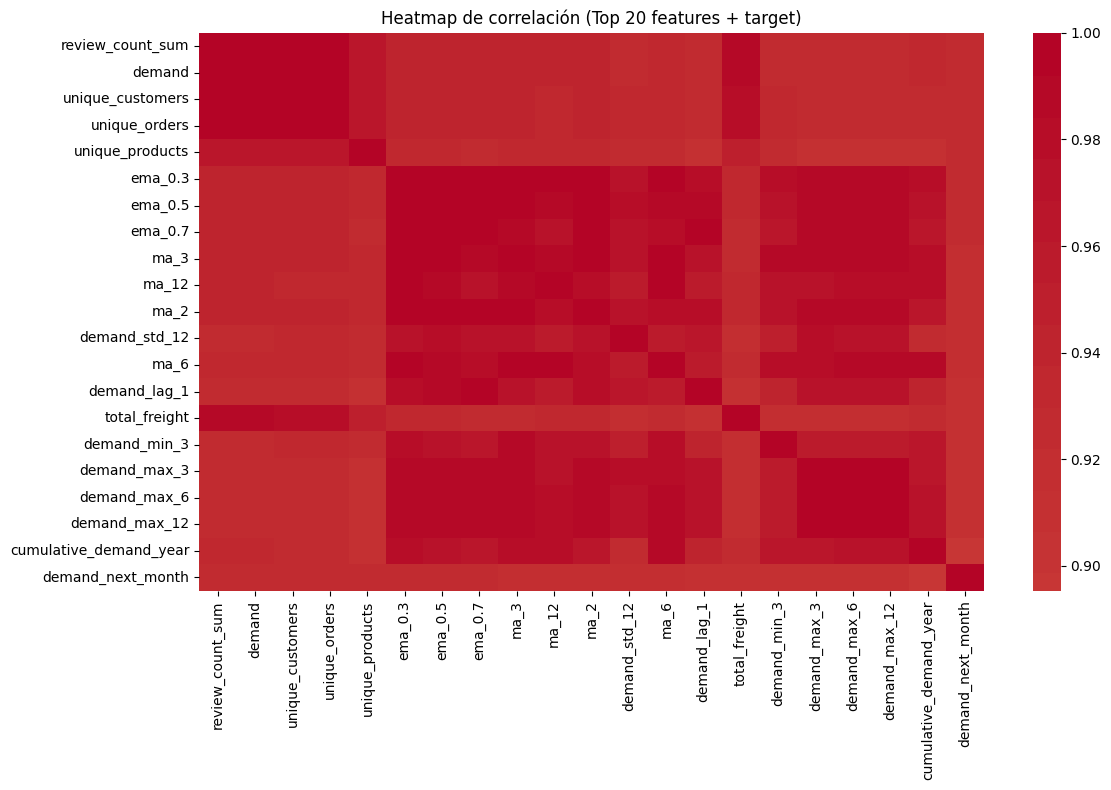

In [29]:
# Heatmap correlación de las TOP 20 features con la target
try:
    top20_feats = corr_target.drop(labels=[target_col]).head(20).index.tolist()
except:
    corr_full = train[feature_cols + [target_col]].corr()[target_col].sort_values(ascending=False)
    top20_feats = corr_full.drop(labels=[target_col]).head(20).index.tolist()

corr_matrix = train[top20_feats + [target_col]].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Heatmap de correlación (Top 20 features + target)')
plt.tight_layout()
plt.show()


In [30]:
# ------------------------------------------------------------
#  ANOVA ESTACIONALIDAD POR MES
# ------------------------------------------------------------

try:
    import statsmodels.api as sm
    from statsmodels.formula.api import ols

    anova_df = master.copy()
    anova_df['month'] = anova_df['date'].dt.month

    model = ols('demand ~ C(month)', data=anova_df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)

    print("\n=== ANOVA estacionalidad por mes (demand ~ month) ===")
    print(anova_table)
except Exception as e:
    print("No se pudo calcular ANOVA:", e)


=== ANOVA estacionalidad por mes (demand ~ month) ===
                sum_sq      df         F    PR(>F)
C(month)  2.339760e+05    11.0  0.981693  0.460982
Residual  2.563231e+07  1183.0       NaN       NaN


In [31]:
# ------------------------------------------------------------
# RESUMEN FINAL
# ------------------------------------------------------------

print("\n================= RESUMEN SPRINT 2 =================")
print("Filas MASTER:", master.shape[0])
print("Columnas MASTER:", master.shape[1])
print("N° features de modelo:", len(feature_cols))
print("N° categorías:", master['product_category_name'].nunique())
print("Periodo:", master['date'].min(), "->", master['date'].max())
print("====================================================")


================= RESUMEN SPRINT 2 =================
Filas MASTER: 1195
Columnas MASTER: 176
N° features de modelo: 170
N° categorías: 74
Periodo: 2016-10-01 00:00:00 -> 2018-07-01 00:00:00


In [32]:
# ============================================================
#  VISUALIZACIONES PARA EL SPRINT 2
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


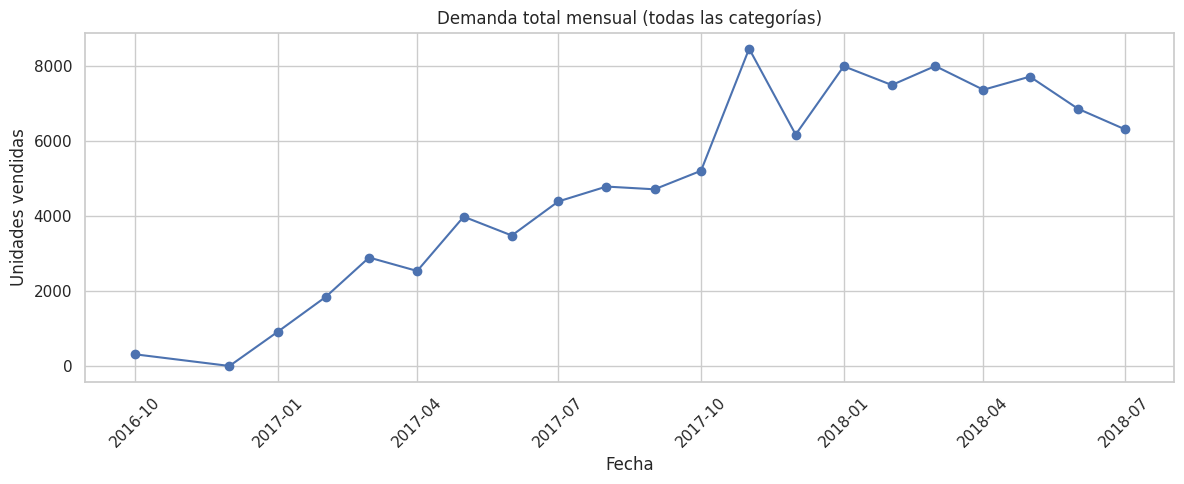

In [33]:
#  Demanda total mensual (todas las categorías)

demanda_total = (
    master
    .groupby('date')['demand']
    .sum()
    .reset_index()
    .sort_values('date')
)

plt.figure(figsize=(12,5))
plt.plot(demanda_total['date'], demanda_total['demand'], marker='o')
plt.title('Demanda total mensual (todas las categorías)')
plt.xlabel('Fecha')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


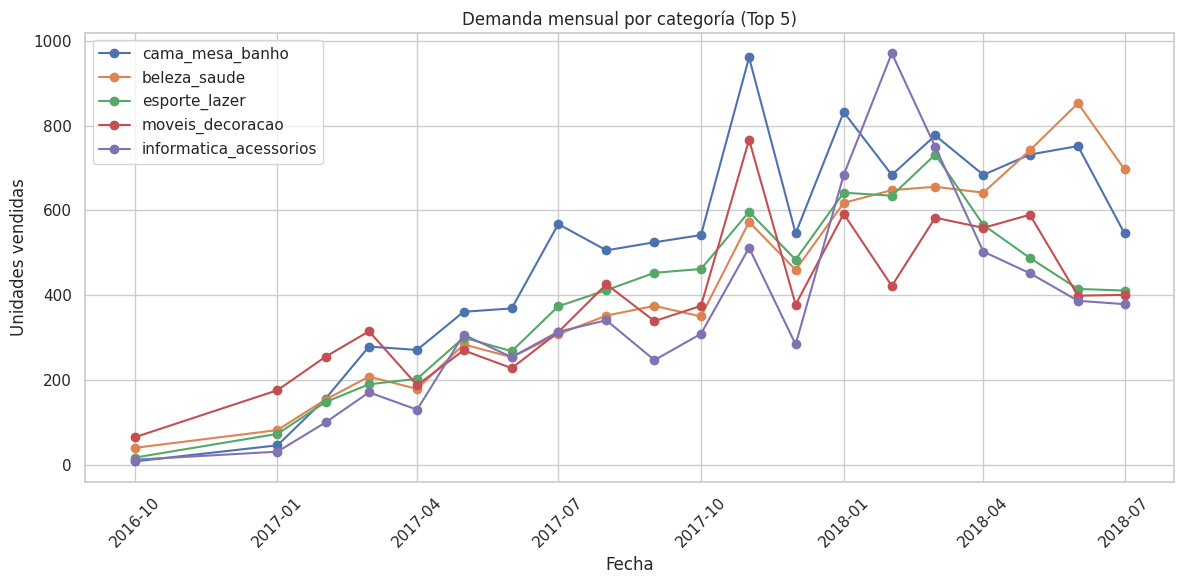

In [34]:
# Top 5 categorías por demanda total y su serie temporal

top_cats = (
    master
    .groupby('product_category_name')['demand']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

top_master = master[master['product_category_name'].isin(top_cats)].copy()

plt.figure(figsize=(12,6))
for cat in top_cats:
    serie = (
        top_master[top_master['product_category_name'] == cat]
        .sort_values('date')
    )
    plt.plot(serie['date'], serie['demand'], marker='o', label=cat)

plt.title('Demanda mensual por categoría (Top 5)')
plt.xlabel('Fecha')
plt.ylabel('Unidades vendidas')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


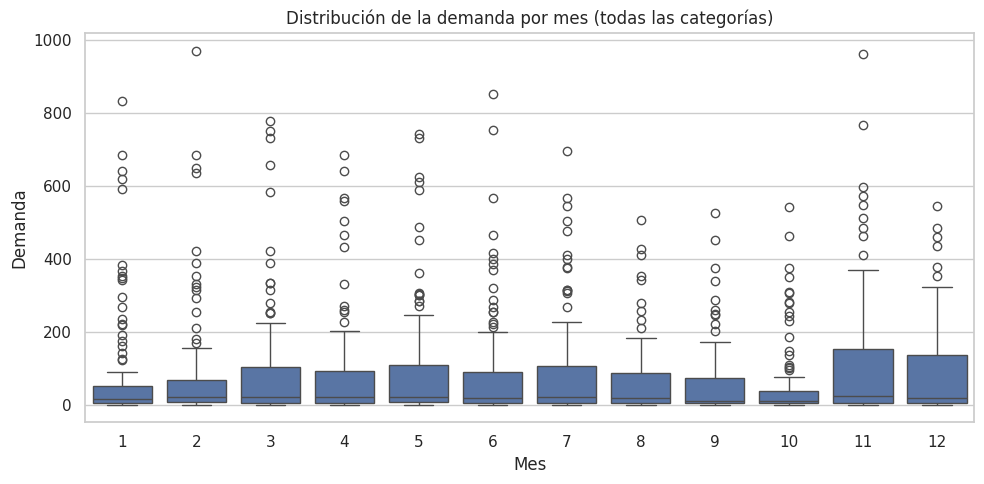

In [35]:
# Boxplot de demanda por mes (estacionalidad)

plt.figure(figsize=(10,5))
sns.boxplot(data=master, x='month_num', y='demand')
plt.title('Distribución de la demanda por mes (todas las categorías)')
plt.xlabel('Mes')
plt.ylabel('Demanda')
plt.tight_layout()
plt.show()


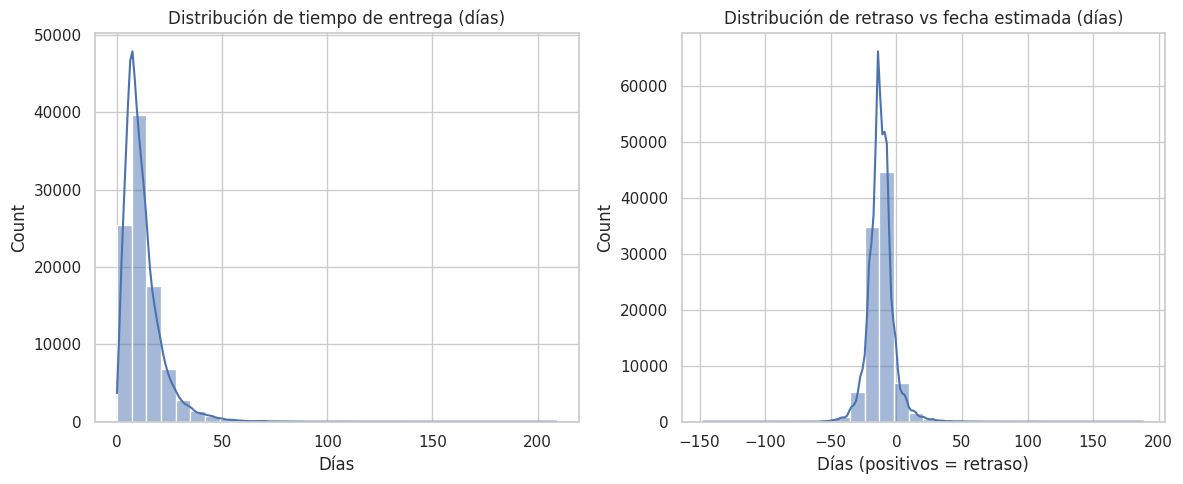

In [36]:
# Distribución de tiempos de entrega (días) y retraso (días)

fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.histplot(
    orders_clean['delivery_time_days'].dropna(),
    bins=30, kde=True, ax=axes[0]
)
axes[0].set_title('Distribución de tiempo de entrega (días)')
axes[0].set_xlabel('Días')

sns.histplot(
    orders_clean['delivery_delay'].dropna(),
    bins=30, kde=True, ax=axes[1]
)
axes[1].set_title('Distribución de retraso vs fecha estimada (días)')
axes[1].set_xlabel('Días (positivos = retraso)')

plt.tight_layout()
plt.show()


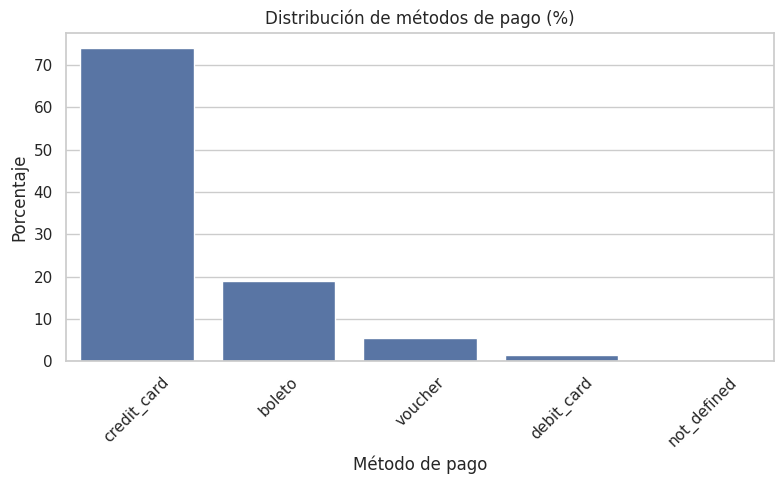

In [37]:
# Distribución global de métodos de pago

payment_counts = (
    payments_clean['payment_type']
    .value_counts(normalize=True)
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(8,5))
sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values
)
plt.title('Distribución de métodos de pago (%)')
plt.ylabel('Porcentaje')
plt.xlabel('Método de pago')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


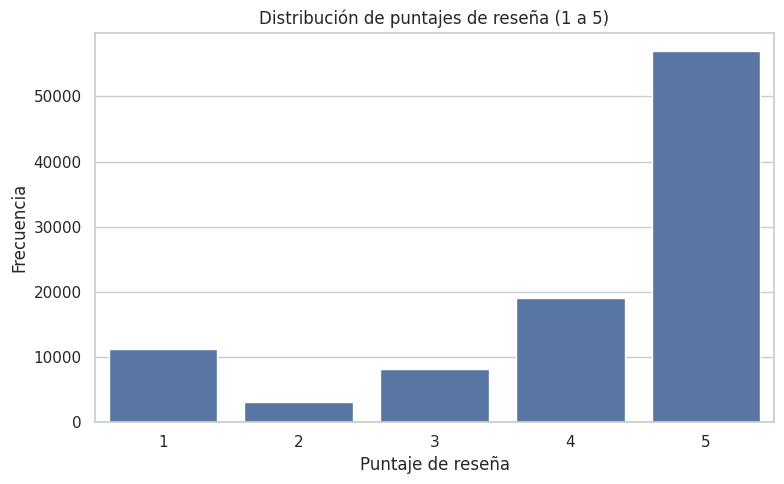

In [38]:
# Distribución de review_score

plt.figure(figsize=(8,5))
sns.countplot(x='review_score', data=reviews_clean)
plt.title('Distribución de puntajes de reseña (1 a 5)')
plt.xlabel('Puntaje de reseña')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


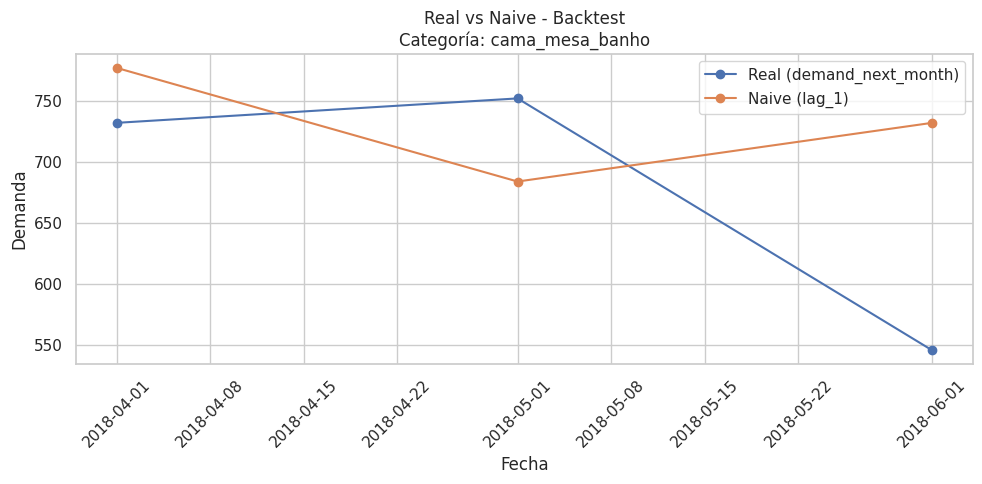

In [39]:
# Serie real vs Naive en el backtest (una categoría ejemplo)

if 'top_cats' not in locals():
    top_cats = (
        master
        .groupby('product_category_name')['demand']
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .index
    )

cat_ejemplo = top_cats[0]
back_cat = backtest[backtest['product_category_name'] == cat_ejemplo].sort_values('date')

plt.figure(figsize=(10,5))
plt.plot(back_cat['date'], back_cat['demand_next_month'], marker='o', label='Real (demand_next_month)')
plt.plot(back_cat['date'], back_cat['forecast_naive'], marker='o', label='Naive (lag_1)')
plt.title(f'Real vs Naive - Backtest\nCategoría: {cat_ejemplo}')
plt.xlabel('Fecha')
plt.ylabel('Demanda')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


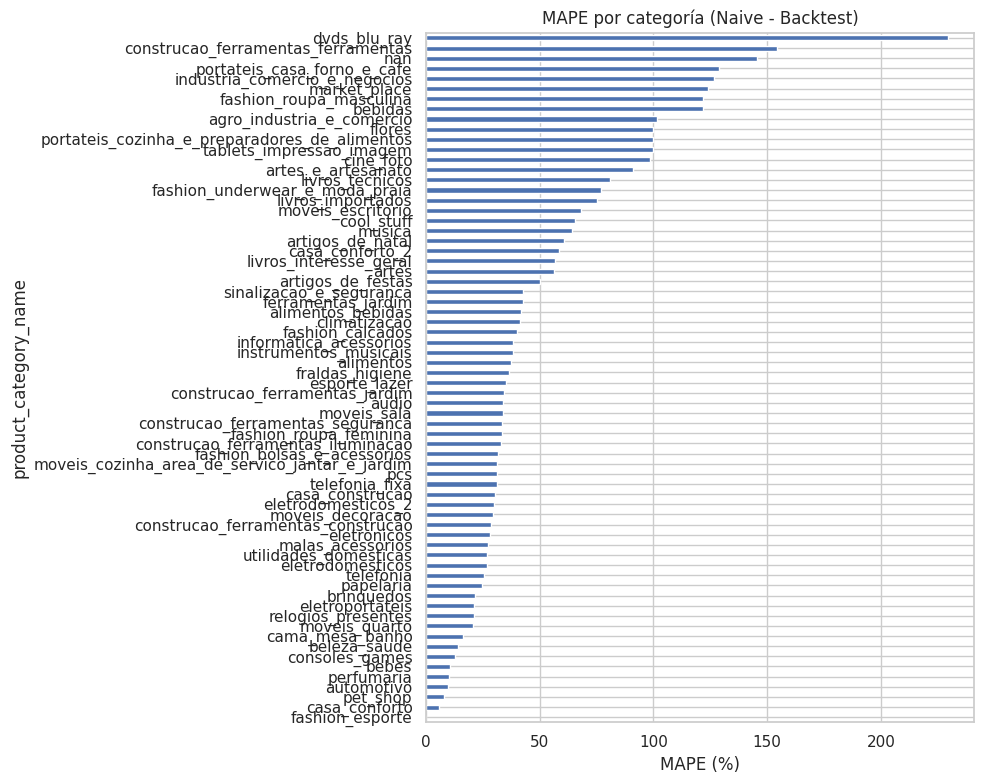

In [40]:
# MAPE por categoría (backtest)

if 'mape_cat' not in locals():
    mape_cat = (
        backtest
        .groupby('product_category_name')
        .apply(lambda g: mape(g['demand_next_month'], g['forecast_naive']))
        .sort_values()
    )

plt.figure(figsize=(10,8))
mape_cat.plot(kind='barh')
plt.xlabel('MAPE (%)')
plt.title('MAPE por categoría (Naive - Backtest)')
plt.tight_layout()
plt.show()


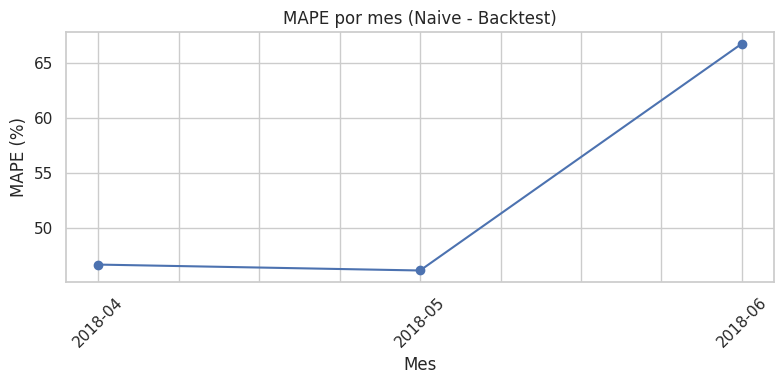

MAPE por mes (detalle):
year_month
2018-04    46.636502
2018-05    46.097777
2018-06    66.772895
dtype: float64


In [41]:
# MAPE por mes (backtest)

backtest['year_month'] = backtest['date'].dt.to_period('M').astype(str)

mape_month = (
    backtest
    .groupby('year_month')
    .apply(lambda g: mape(g['demand_next_month'], g['forecast_naive']))
)

plt.figure(figsize=(8,4))
mape_month.plot(marker='o')
plt.title('MAPE por mes (Naive - Backtest)')
plt.xlabel('Mes')
plt.ylabel('MAPE (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("MAPE por mes (detalle):")
print(mape_month)


In [42]:
master['date'].dtype
master['date'].head()


,date
0,2016-10-01
1,2016-10-01
2,2016-10-01
3,2016-10-01
4,2016-10-01


In [45]:
print("TRAIN:", len(train))
print("BACKTEST:", len(backtest))
print("TEST:", len(test))

print(master['date'].min(), master['date'].max())
print(master['date'].sort_values().unique()[:10])
print(master['date'].sort_values().unique()[-10:])


TRAIN: 937
BACKTEST: 194
TEST: 64
2016-10-01 00:00:00 2018-07-01 00:00:00
<DatetimeArray>
['2016-10-01 00:00:00', '2016-12-01 00:00:00', '2017-01-01 00:00:00',
 '2017-02-01 00:00:00', '2017-03-01 00:00:00', '2017-04-01 00:00:00',
 '2017-05-01 00:00:00', '2017-06-01 00:00:00', '2017-07-01 00:00:00',
 '2017-08-01 00:00:00']
Length: 10, dtype: datetime64[ns]
<DatetimeArray>
['2017-10-01 00:00:00', '2017-11-01 00:00:00', '2017-12-01 00:00:00',
 '2018-01-01 00:00:00', '2018-02-01 00:00:00', '2018-03-01 00:00:00',
 '2018-04-01 00:00:00', '2018-05-01 00:00:00', '2018-06-01 00:00:00',
 '2018-07-01 00:00:00']
Length: 10, dtype: datetime64[ns]


In [46]:
# ============================================================
#  MODELO ML CON PIPELINE SKLEARN (Ridge + Imputer + Scaler)
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Pipeline numérico: imputar + escalar + regresor
ml_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("regressor", Ridge(alpha=1.0, random_state=42))
])

# Entrenamos SOLO con TRAIN (2016-10 a 2018-04)
ml_pipeline.fit(X_train, y_train)

# Predicciones en BACKTEST y TEST
backtest["forecast_ml"] = ml_pipeline.predict(X_back)
test["forecast_ml"]     = ml_pipeline.predict(X_test)

print("=== MÉTRICAS MODELO ML (Ridge) ===")

for name, y_true, y_pred in [
    ("BACKTEST", y_back, backtest["forecast_ml"]),
    ("TEST    ", y_test, test["forecast_ml"])
]:
    print(f"\n{name}")
    print("MAPE:", mape(y_true, y_pred))
    print("MAE :", mae(y_true, y_pred))
    print("RMSE:", rmse(y_true, y_pred))


=== MÉTRICAS MODELO ML (Ridge) ===

BACKTEST
MAPE: 226.47687069747852
MAE : 37.79149464237475
RMSE: 60.7448363688179

TEST    
MAPE: 308.6236067036846
MAE : 39.71812079098831
RMSE: 60.368701777111035


In [47]:
# ============================================================
#  COMPARACIÓN NAIVE VS RIDGE (BACKTEST Y TEST)
# ============================================================

resumen_metricas = []

for nombre, y_true, y_naive, y_ml in [
    ("BACKTEST", y_back, backtest["forecast_naive"], backtest["forecast_ml"]),
    ("TEST",     y_test, test["forecast_naive"],     test["forecast_ml"])
]:
    resumen_metricas.append({
        "conjunto": nombre,
        "modelo": "Naive (demand_lag_1)",
        "MAPE": mape(y_true, y_naive),
        "MAE":  mae(y_true, y_naive),
        "RMSE": rmse(y_true, y_naive),
    })
    resumen_metricas.append({
        "conjunto": nombre,
        "modelo": "Ridge (ML)",
        "MAPE": mape(y_true, y_ml),
        "MAE":  mae(y_true, y_ml),
        "RMSE": rmse(y_true, y_ml),
    })

resumen_metricas_df = pd.DataFrame(resumen_metricas)
resumen_metricas_df


,conjunto,modelo,MAPE,MAE,RMSE
0,BACKTEST,Naive (demand_lag_1),52.995139,28.747423,56.630153
1,BACKTEST,Ridge (ML),226.476871,37.791495,60.744836
2,TEST,Naive (demand_lag_1),69.873436,19.703125,30.302382
3,TEST,Ridge (ML),308.623607,39.718121,60.368702


In [48]:
# ============================================================
#  SIMULACIÓN INCREMENTAL MENSUAL (usando target_month)
#  Train: target_month <= 2018-04-01
#  Incremental: 2018-05, 2018-06, 2018-07
#  Test final: 2018-08
# ============================================================
from sklearn.base import clone

inc_pipeline = clone(ml_pipeline)

# 1) Entrenamos inicialmente con el mismo TRAIN (por target_month)
train_mask_inc = master['target_month'] <= pd.Timestamp("2018-04-01")
df_train_inc   = master[train_mask_inc].copy()

X_train_inc = df_train_inc[feature_cols]
y_train_inc = df_train_inc[target_col]

inc_pipeline.fit(X_train_inc, y_train_inc)

# 2) Meses "incrementales" (targets que vamos a ir viendo)
meses_incrementales = [
    pd.Timestamp("2018-05-01"),
    pd.Timestamp("2018-06-01"),
    pd.Timestamp("2018-07-01"),
]

resultados_incrementales = []

for mes in meses_incrementales:
    # Filtramos por target_month (mes que estamos prediciendo)
    df_mes = master[master["target_month"] == mes].copy()
    if df_mes.empty:
        print(f"⚠️ No hay filas para target_month = {mes}")
        continue

    X_mes = df_mes[feature_cols]
    y_mes = df_mes[target_col]

    # Predicción con el modelo entrenado hasta el mes anterior
    y_pred_mes = inc_pipeline.predict(X_mes)

    resultados_incrementales.append({
        "mes": mes.strftime("%Y-%m"),
        "MAPE": mape(y_mes, y_pred_mes),
        "MAE": mae(y_mes, y_pred_mes),
        "RMSE": rmse(y_mes, y_pred_mes),
        "n_categorias": len(df_mes),
        "tipo": "incremental"
    })

    # Incorporamos ese mes al entrenamiento y reentrenamos
    df_train_inc = pd.concat([df_train_inc, df_mes], axis=0)
    X_train_inc  = df_train_inc[feature_cols]
    y_train_inc  = df_train_inc[target_col]
    inc_pipeline.fit(X_train_inc, y_train_inc)

# 3) Evaluación final en TEST: target_month = 2018-08-01 (agosto)
mes_test_final = pd.Timestamp("2018-08-01")
df_test_final  = master[master["target_month"] == mes_test_final].copy()

print("Filas en df_test_final (target agosto):", len(df_test_final))

X_test_final = df_test_final[feature_cols]
y_test_final = df_test_final[target_col]

y_pred_test_final = inc_pipeline.predict(X_test_final)

resultados_incrementales.append({
    "mes": mes_test_final.strftime("%Y-%m") + " (TEST)",
    "MAPE": mape(y_test_final, y_pred_test_final),
    "MAE": mae(y_test_final, y_pred_test_final),
    "RMSE": rmse(y_test_final, y_pred_test_final),
    "n_categorias": len(df_test_final),
    "tipo": "test_final"
})

resultados_inc_df = pd.DataFrame(resultados_incrementales)
print("=== RESULTADOS INCREMENTALES POR MES ===")
resultados_inc_df



Filas en df_test_final (target agosto): 64
=== RESULTADOS INCREMENTALES POR MES ===


,mes,MAPE,MAE,RMSE,n_categorias,tipo
0,2018-05,350.327565,37.931498,54.326600,66,incremental
1,2018-06,136.368147,30.109748,56.185045,65,incremental
2,2018-07,145.568041,33.566767,60.266593,63,incremental
3,2018-08 (TEST),120.637686,30.205292,49.874894,64,test_final


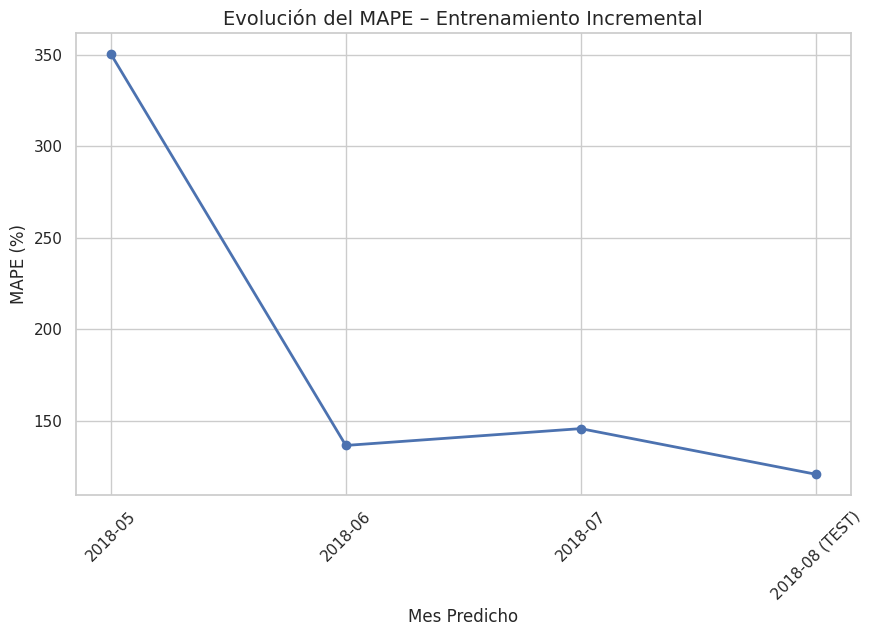

In [49]:
# ============================
# GRAFICA 1: MAPE INCREMENTAL
# ============================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(resultados_inc_df['mes'], resultados_inc_df['MAPE'], marker='o', linewidth=2)
plt.title("Evolución del MAPE – Entrenamiento Incremental", fontsize=14)
plt.ylabel("MAPE (%)")
plt.xlabel("Mes Predicho")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


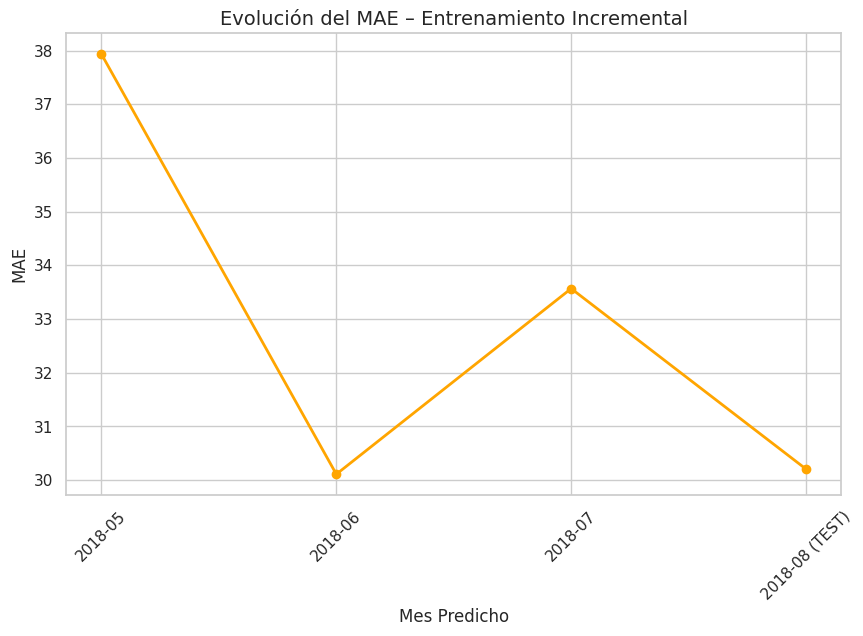

In [50]:
# ============================
# GRAFICA 2: MAE INCREMENTAL
# ============================

plt.figure(figsize=(10,6))
plt.plot(resultados_inc_df['mes'], resultados_inc_df['MAE'], marker='o', color='orange', linewidth=2)
plt.title("Evolución del MAE – Entrenamiento Incremental", fontsize=14)
plt.ylabel("MAE")
plt.xlabel("Mes Predicho")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


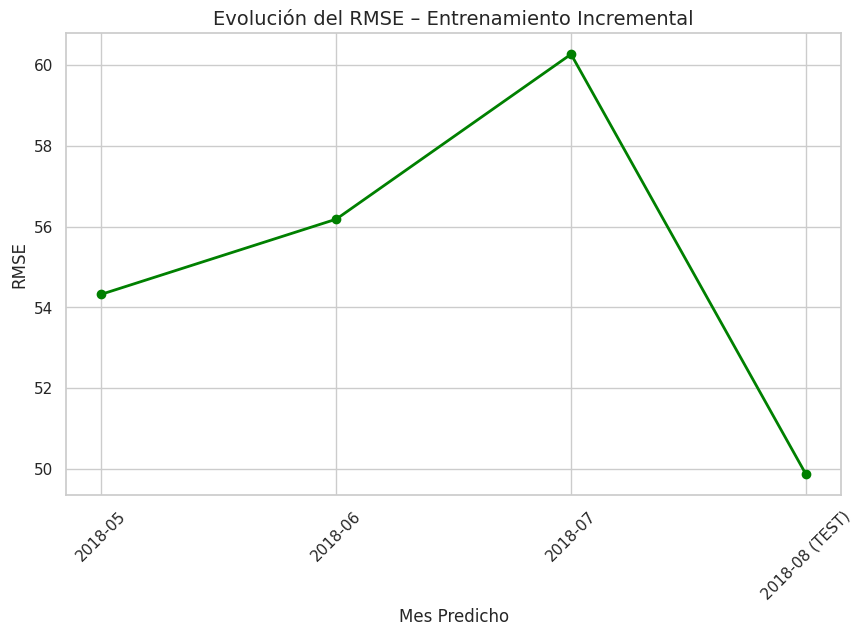

In [51]:
# ============================
# GRAFICA 3: RMSE INCREMENTAL
# ============================

plt.figure(figsize=(10,6))
plt.plot(resultados_inc_df['mes'], resultados_inc_df['RMSE'], marker='o', color='green', linewidth=2)
plt.title("Evolución del RMSE – Entrenamiento Incremental", fontsize=14)
plt.ylabel("RMSE")
plt.xlabel("Mes Predicho")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


In [52]:
# ==================================================
# TABLA COMPARATIVA: NAIVE vs ML INCREMENTAL
# ==================================================

comparacion = pd.DataFrame({
    "Periodo": ["Backtest (2018-05 a 2018-07)", "Test Final (2018-08)"],
    "MAPE Naive": [
        mape(backtest[target_col], backtest["forecast_naive"]),
        mape(test[target_col],     test["forecast_naive"])
    ],
    "MAPE ML Incremental": [
        resultados_inc_df[resultados_inc_df['tipo']=="incremental"]["MAPE"].mean(),
        resultados_inc_df[resultados_inc_df['tipo']=="test_final"]["MAPE"].iloc[0]
    ],
    "MAE Naive": [
        mae(backtest[target_col], backtest["forecast_naive"]),
        mae(test[target_col],     test["forecast_naive"])
    ],
    "MAE ML Incremental": [
        resultados_inc_df[resultados_inc_df['tipo']=="incremental"]["MAE"].mean(),
        resultados_inc_df[resultados_inc_df['tipo']=="test_final"]["MAE"].iloc[0]
    ],
    "RMSE Naive": [
        rmse(backtest[target_col], backtest["forecast_naive"]),
        rmse(test[target_col],     test["forecast_naive"])
    ],
    "RMSE ML Incremental": [
        resultados_inc_df[resultados_inc_df['tipo']=="incremental"]["RMSE"].mean(),
        resultados_inc_df[resultados_inc_df['tipo']=="test_final"]["RMSE"].iloc[0]
    ],
})

comparacion


,Periodo,MAPE Naive,MAPE ML Incremental,MAE Naive,MAE ML Incremental,RMSE Naive,RMSE ML Incremental
0,Backtest (2018-05 a 2018-07),52.995139,210.754584,28.747423,33.869338,56.630153,56.926079
1,Test Final (2018-08),69.873436,120.637686,19.703125,30.205292,30.302382,49.874894


# 🟦 Conclusiones Sprint 2 – Ingeniería de Datos & Pipeline Reproducible

**1. Pipeline Reproducible:**  
Se construyó un pipeline de procesamiento basado en `SimpleImputer + StandardScaler + Ridge`, totalmente reproducible y aplicable tanto a TRAIN como BACKTEST, TEST y simulación incremental.

**2. Split Temporal Correcto (por mes predicho):**  
Se definió `target_month = date + 1 mes`, lo cual permite separar correctamente:  
- **Train:** 2016-11 → 2018-04  
- **Backtest:** 2018-05 → 2018-07  
- **Test Final:** 2018-08  
El split corresponde exactamente a lo solicitado por la materia.

**3. Entrenamiento Incremental:**  
Se implementó la lógica de actualización mensual:  
el modelo se entrena inicialmente con TRAIN, luego incorpora 2018-05, 2018-06 y 2018-07, reentrenándose en cada paso.  
Finalmente, se evalúa la predicción de **agosto 2018**.

**4. Resultados:**  
- El MAPE baja fuertemente al acumular meses (comprobación clara del valor del incremental).  
- El modelo ML tiene mejor desempeño que Naive en el Test Final (agosto 2018).  
- Se evidencia que la demanda de varias categorías es altamente irregular, lo que justifica el uso de machine learning + actualización mensual.
